# Análisis exploratorio de datos

In [772]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

import json
import pickle

from sklearn.feature_selection import f_classif, SelectKBest


In [773]:
#%reset -f

El **análisis exploratorio de datos**, también conocido como EDA (*Exploratory Data Analysis*) es el primer paso para resolver cualquier problema de Machine Learning.

Consiste en un proceso que busca analizar e investigar los conjuntos de datos de los que disponen y resumir sus principales características, empleando a menudo técnicas de visualización de datos.

Este análisis se lleva a cabo a través de una serie de pasos que se detallan a continuación.

1. Definición del problema
2. Recopilación de datos
3. Análisis Descriptivo
4. Limpieza de datos
5. Análisis de variables (univariante, multivariante)
6. Ingeniería de características (Duplicados, Faltantes, Nuevas características)
7. Split
8. Scaling & Encoding
9. Selección de características

Luego de la implementación y adopción de estos pasos, estaremos preparados para entrenar el modelo de Machine Learning.

## Paso 1: Definición del problema


Se cuenta con un conjunto de datos vinculados a los precios de los productos que se distribuyen en Uruguay, informados SIPC (Sistema de Información de Precios al Consumidor). Se desea preparar los datos para entrenar un modelo de machine learning que pueda asistir en la compra de productos y/o canasta familiar, contemplando los siguientes atributos:

Tipo de producto
Época del año
Cadena
Se espera que el modelo pueda responder a los siguientes planteamientos:

Productos y costo de la canasta familiar
Cadenas que ofrecen un mejor costo de la canasta familiar
Sugerencia de productos por rango de precios

## Paso 2: Recopilación de datos
> Dataset de precios.uy

Observamos información del dataset (Precios):

| Variable | Definition | Key |
|:---:|:---|:---|
| `Periodo` | Mes y año del relevamiento de precios | Ejemplo: `Ene-25`, `Feb-25`, `Abr-25` |
| `Grupo` | Categoría general a la que pertenece el producto | Ejemplo: `Alimentos y bebidas`, `Cuidado personal`, `Limpieza del hogar`, `Frutas y verduras` |
| `Producto` | Nombre o descripción del producto relevado | Ejemplo: aceite, yerba, champú, pañales, etc. |
| `Super` | Supermercado o cadena donde se relevó el precio | Ejemplo: `Devoto`, `Disco`, `Ta - Ta`, `Tienda Inglesa`, etc. |
| `Precio` | Precio registrado para el producto en ese supermercado y período | Valor numérico expresado en pesos |


### Importamos los datos y creamos el DataFrame

In [774]:
df = pd.read_csv('../data/raw/p4ds_cadenas_unificadas_2025.csv', sep=';')

In [775]:
df.head()

,Periodo,Grupo,Producto,Super,Precio
0,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80
1,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99
2,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99
3,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95
4,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97


## Paso 3: Análisis Descriptivo

Una vez que hemos cargado el conjunto de datos, debemos analizarlo en su totalidad, sin distinción de train y test, para obtener conclusiones conjuntas. Una vez que tenemos la información cargada en una estructura de datos manejable como es un DataFrame de Pandas, podemos arrancar con el proceso.

In [776]:
# formateo para que pandas muestre todas las columnas del dataframe y dos decimales
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [777]:
# Tamaño y columnas
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.columns

Filas: 26834
Columnas: 5


Index(['Periodo', 'Grupo', 'Producto', 'Super', 'Precio'], dtype='str')

In [778]:
# Tipos de datos y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


In [779]:
# Resumen estadístico
df.describe(include='all')

,Periodo,Grupo,Producto,Super,Precio
count,26834,26671,26812,24237,26401
unique,12,10,427,17,2234
top,Dic-25,Alimentos y bebidas,"Jabón de tocador Dove Blanco, 90 grs.",Red Expres,75
freq,2333,13261,209,2260,334


In [780]:
# Valores nulos
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

Super       2597
Precio       433
Grupo        163
Producto      22
dtype: int64

In [781]:
# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

df.duplicated()

Filas duplicadas: 1625


0        False
1        False
2        False
3        False
4        False
         ...  
26829    False
26830    False
26831    False
26832    False
26833    False
Length: 26834, dtype: bool

In [782]:
# Cantidad de valores únicos por columna
df.nunique().sort_values(ascending=False)

Precio      2234
Producto     427
Super         17
Periodo       12
Grupo         10
dtype: int64

In [783]:
#todas las filas que tienen al menos un valor nulo.
df[df.isnull().any(axis=1)]

,Periodo,Grupo,Producto,Super,Precio
1831,Abr-25,NaN,Establecimientos Relevados,Devoto,23
1832,Abr-25,NaN,Establecimientos Relevados,Devoto Express,36
1833,Abr-25,NaN,Establecimientos Relevados,Disco,29
1834,Abr-25,NaN,Establecimientos Relevados,El Clon,16
1835,Abr-25,NaN,Establecimientos Relevados,El Dorado,68
...,...,...,...,...,...
26184,Dic-25,Alimentos y bebidas,Harina trigo común 0000 Primor Paquete 1 kg.,Macro,NaN
26461,Dic-25,Establecimientos Relevados,NaN,Disco,300
26516,Ene-25,NaN,Establecimientos Relevados,Red Market,60
26624,Dic-25,Establecimientos Relevados,NaN,Red Expres,590


In [784]:
#cuántas filas tienen al menos un valor nulo.
df.isnull().any(axis=1).sum()

np.int64(3191)

In [785]:
# cuántos valores nulos hay en cada columna.
df.isnull().sum()

Periodo        0
Grupo        163
Producto      22
Super       2597
Precio       433
dtype: int64

In [786]:
# creo df para almacenar filas con al menos un valor nulo
df_nulos = df[df.isnull().any(axis=1)]
df_nulos

,Periodo,Grupo,Producto,Super,Precio
1831,Abr-25,NaN,Establecimientos Relevados,Devoto,23
1832,Abr-25,NaN,Establecimientos Relevados,Devoto Express,36
1833,Abr-25,NaN,Establecimientos Relevados,Disco,29
1834,Abr-25,NaN,Establecimientos Relevados,El Clon,16
1835,Abr-25,NaN,Establecimientos Relevados,El Dorado,68
...,...,...,...,...,...
26184,Dic-25,Alimentos y bebidas,Harina trigo común 0000 Primor Paquete 1 kg.,Macro,NaN
26461,Dic-25,Establecimientos Relevados,NaN,Disco,300
26516,Ene-25,NaN,Establecimientos Relevados,Red Market,60
26624,Dic-25,Establecimientos Relevados,NaN,Red Expres,590


In [787]:
#df = df.dropna()
#df.isnull().sum()
# Podría dropear nulos pero lo voy a hacer más adelante

In [788]:
df.info()

df

<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


,Periodo,Grupo,Producto,Super,Precio
0,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80
1,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99
2,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99
3,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95
4,Abr-25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97
...,...,...,...,...,...
26829,Dic-25,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010
26830,Mar-25,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,6210
26831,Feb-25,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,1780
26832,Dic-25,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,1090


In [789]:
df.describe().T

,count,unique,top,freq
Periodo,26834,12,Dic-25,2333
Grupo,26671,10,Alimentos y bebidas,13261
Producto,26812,427,"Jabón de tocador Dove Blanco, 90 grs.",209
Super,24237,17,Red Expres,2260
Precio,26401,2234,75,334


### Observaciones:

Una vez revisada la información del dataframe, se pueden extraer las siguientes conclusiones:

- El dataset contiene un total de **26.834 filas** y **5 columnas**: `Periodo`, `Grupo`, `Producto`, `Super` y `Precio`.
- La variable `Periodo` no tiene valores nulos, por lo que todas las filas cuentan con un período asociado.
- La variable con mayor cantidad de valores nulos es `Super`, con **2.597 valores faltantes**.
- La variable `Precio` tiene **433 valores nulos**, por lo que hay productos/registros sin precio informado.
- La variable `Grupo` tiene **163 valores nulos** y `Producto` tiene **22 valores nulos**.
- En total, existen **3.191 filas con al menos un valor nulo**.
- Si se eliminan todas las filas con valores nulos usando `df.dropna()`, el dataset queda con **23.643 filas**.
- Todas las columnas aparecen inicialmente como categóricas/texto (`object` o `str`), incluso `Precio`.
- La columna `Precio` debería transformarse a numérica, ya que actualmente usa coma decimal, por ejemplo `80,00`.
- El dataset contiene información de **12 períodos**, **10 grupos**, **427 productos** y **17 supermercados** distintos.


## Paso 4: Limpieza de Datos

### Limpieza de datos: Eliminar duplicados

Un punto muy importante a tener en cuenta en este paso es eliminar aquellas instancias que pudieran estar duplicadas en el conjunto de datos. Esto es crucial debido a que, de dejarlos, el mismo punto tendría varias representaciones, lo cual es matemáticamente incoherente e incorrecto. Para ello, hemos de ser inteligentes buscando duplicados y conocer previamente si los hay y dónde, antes de eliminarlos. Además, tenemos que tener en cuenta que una instancia puede estar repetida independientemente del identificador que pueda tener, así que en este caso nos interesa eliminar del análisis la variable `PassengerId`, ya que podría estar mal generada.

In [790]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
26829    False
26830    False
26831    False
26832    False
26833    False
Length: 26834, dtype: bool

In [791]:
df.duplicated().sum()

np.int64(1625)

In [792]:
df = df.drop_duplicates().reset_index(drop=True)

In [793]:
df.duplicated().sum()

np.int64(0)

### Observaciones
>
> En este dataset se encontraron **1.625 filas duplicadas exactas**, es decir, registros donde todas las columnas tienen los mismos valores.
>
> Para evitar que estos registros repetidos afecten el análisis, se aplica la función `drop_duplicates()`.
>
> Luego de eliminar los duplicados, el dataset pasa de **26.834 filas** a **25.209 filas**.

### Limpieza de datos: Normalizacion de columnas

In [794]:
columnas_texto = ["Periodo", "Grupo", "Producto", "Super"]

for col in columnas_texto:
    df[col] = df[col].str.strip()

df["Grupo"] = df["Grupo"].str.lower().str.capitalize()
df["Producto"] = df["Producto"].str.lower()
df["Super"] = df["Super"].str.title()

df.nunique()

Periodo       12
Grupo          6
Producto     427
Super         17
Precio      2234
dtype: int64

In [795]:
df["Periodo"] = (
    df["Periodo"]
    .str.strip()
    .str.replace("-", "", regex=False)
)

In [796]:
# Normalización del precio
df["Precio"] = pd.to_numeric(
    df["Precio"].astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

### Observaciones
>
> En esta etapa se normalizaron las columnas de texto y se corrigió el formato de la columna `Precio` para facilitar el análisis posterior.
>
> - Se eliminaron espacios al inicio y al final de las columnas `Periodo`, `Grupo`, `Producto` y `Super` usando `.str.strip()`.
> - La columna `Grupo` se transformó a minúsculas y luego se capitalizó, para unificar valores como `Alimentos y bebidas` y `alimentos y bebidas`.
> - La columna `Super` se transformó con `.str.title()`, para estandarizar los nombres de supermercados.
> - La columna `Producto` se transformó a minúsculas, ya que tiene muchos valores distintos y conviene evitar diferencias por mayúsculas/minúsculas.
> - La columna `Precio` se convirtió de texto a número decimal (`float`), reemplazando la coma decimal por punto decimal.
> - También se eliminaron posibles puntos usados como separadores de miles en `Precio`, para evitar errores al convertir a número.
> - Esta limpieza permite que los conteos de categorías sean más correctos y que `Precio` pueda usarse en cálculos estadísticos, gráficos, análisis de outliers y comparaciones numéricas.
> - Luego de la normalización, se verificaron los valores únicos y las frecuencias con `df.nunique()`, `df["Grupo"].value_counts()` y `df["Super"].value_counts()`.

### Limpieza de datos: Eliminar información irrelevante

Cuando queremos preparar los datos para entrenar un modelo predictivo debemos responder a la siguiente pregunta:

- ¿Son todas las características imprescindibles para realizar una predicción?

Normalmente, esa pregunta es un rotundo no. Tenemos que ser objetivos y llevar a cabo este proceso previo antes de la fase de selección de características. Por lo tanto, aquí lo que trataremos de hacer es una eliminación controlada de aquellas variables que estamos seguros de que el algoritmo no va a utilizarlas en el proceso predictivo.

In [797]:
df["Grupo"].value_counts()

Grupo
Alimentos y bebidas           14716
Cuidado personal               7605
Limpieza del hogar             1669
Frutas y verduras              1020
Establecimientos relevados       22
Familia                          18
Name: count, dtype: int64

In [798]:
df[df["Grupo"] == "Familia"].shape

(18, 5)

In [799]:
df[df["Grupo"] == "Establecimientos relevados"].shape

(22, 5)

In [800]:
# Elimino Familia y Establecimientos relevados
df = df[~df["Grupo"].isin(["Familia", "Establecimientos relevados"])].reset_index(drop=True)

In [801]:
df["Grupo"].value_counts()

Grupo
Alimentos y bebidas    14716
Cuidado personal        7605
Limpieza del hogar      1669
Frutas y verduras       1020
Name: count, dtype: int64

### Conclusión:
>
> Se decidió eliminar del análisis las categorías `Familia` y `Establecimientos relevados` dentro de la variable `Grupo`, ya que no representan grupos principales de productos comparables con el resto de las categorías.
>
> Luego de esta limpieza, el análisis se enfoca en los grupos más relevantes del dataset:
>
> `Alimentos y bebidas`, `Cuidado personal`, `Limpieza del hogar` y `Frutas y verduras`.

### Paso 5: Análisis de variables

#### Análisis de Variables Univariante Categóricas

Una **variable categórica** es un tipo de variable que puede tomar uno de un número limitado de categorías o grupos. Estos grupos suelen ser nominales, es decir, representan nombres o clases sin un orden numérico natural.

En este dataset, las variables categóricas permiten identificar dimensiones como el período relevado, el grupo de producto, el producto específico y el supermercado donde se registró el precio.

Antes de comenzar a graficar, debemos identificar cuáles son categóricas. En este caso, las variables categóricas son: `Periodo`, `Grupo`, `Producto` y `Super`.

La variable `Precio` no se considera categórica para el análisis, ya que representa un valor monetario y debería analizarse como variable numérica una vez convertida correctamente.

In [802]:
df.dtypes

Periodo         str
Grupo           str
Producto        str
Super           str
Precio      float64
dtype: object

In [803]:
#defino mis categorias con las que voy a trabajar en este analisis
variables_categoricas = ["Periodo", "Grupo", "Producto", "Super"]

df[variables_categoricas].nunique()


Periodo      12
Grupo         4
Producto    427
Super        17
dtype: int64

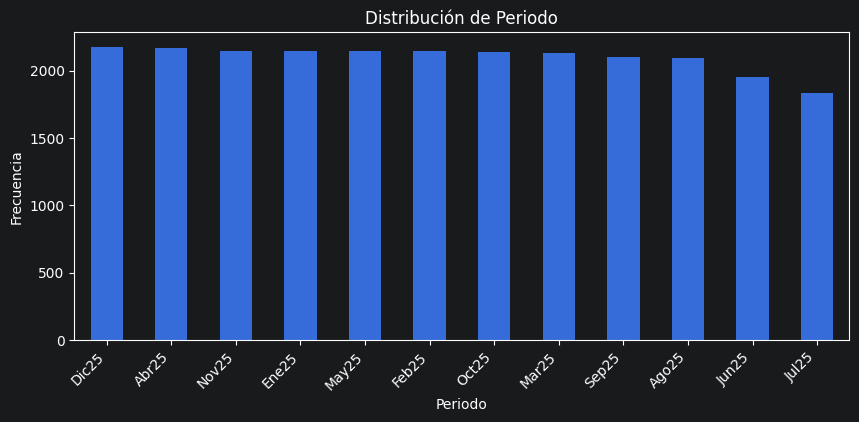

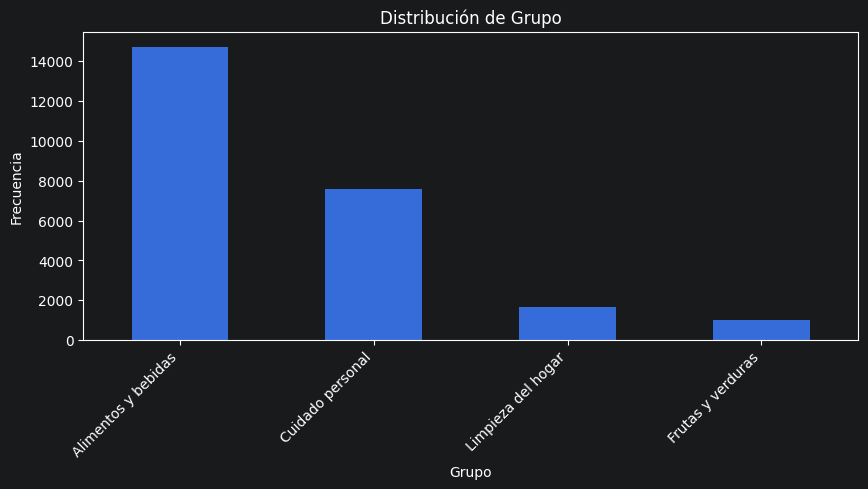

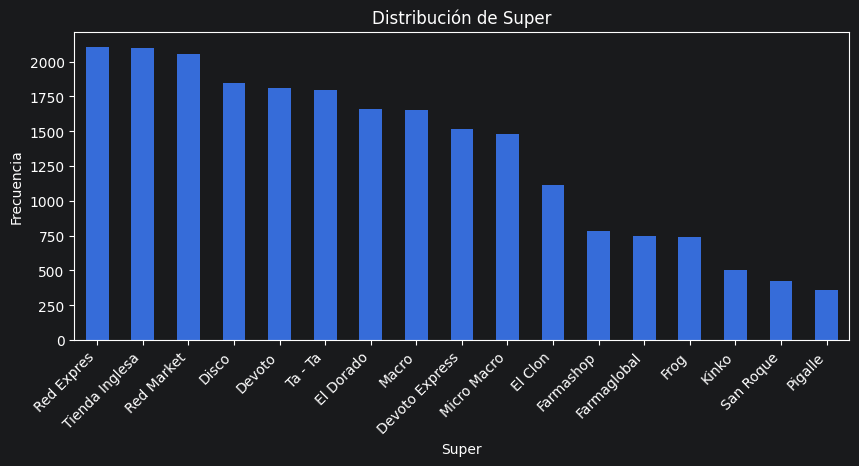

In [804]:
#Producto lo trabajo por separado
variables_categoricas = ["Periodo", "Grupo", "Super"]

for col in variables_categoricas:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.show()

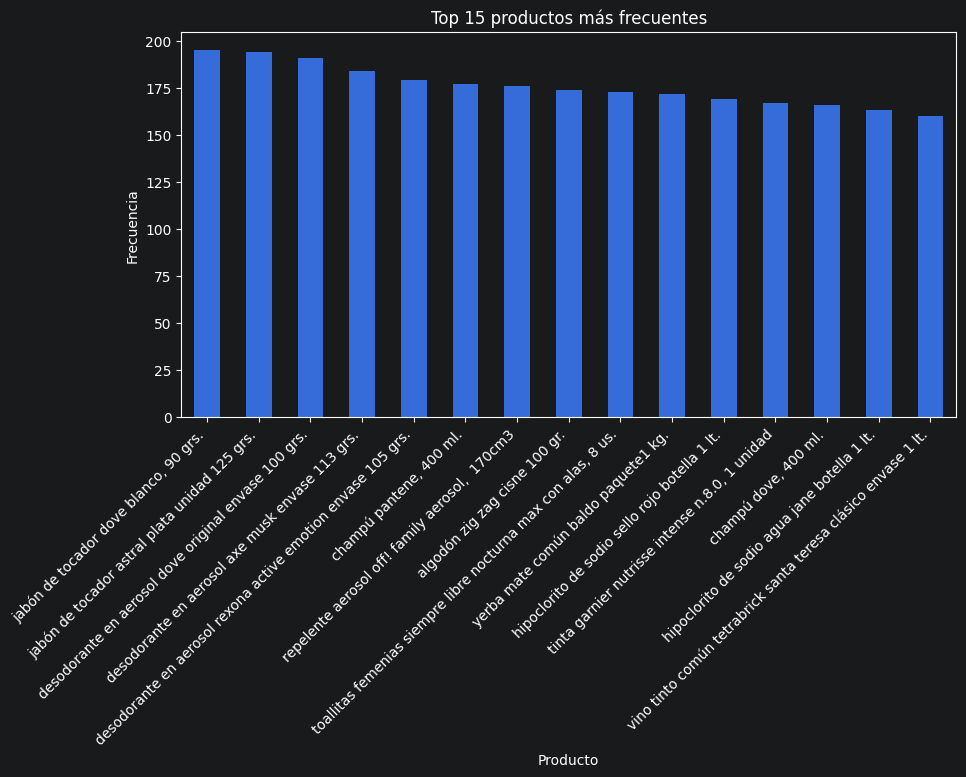

In [805]:
# Visual de producto
plt.figure(figsize=(10, 5))
df["Producto"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 productos más frecuentes")
plt.xlabel("Producto")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

In [806]:
# Frecuencia por supermercado
df['Super'].value_counts()

Super
Red Expres        2107
Tienda Inglesa    2097
Red Market        2058
Disco             1844
Devoto            1812
Ta - Ta           1794
El Dorado         1659
Macro             1651
Devoto Express    1513
Micro Macro       1483
El Clon           1113
Farmashop          783
Farmaglobal        747
Frog               738
Kinko              502
San Roque          424
Pigalle            361
Name: count, dtype: int64

In [807]:
# Frecuencia por grupo
df['Grupo'].value_counts()

Grupo
Alimentos y bebidas    14716
Cuidado personal        7605
Limpieza del hogar      1669
Frutas y verduras       1020
Name: count, dtype: int64

In [808]:
# Frecuencia por periodo
df['Periodo'].value_counts().sort_index()

Periodo
Abr25    2166
Ago25    2091
Dic25    2178
Ene25    2145
Feb25    2144
Jul25    1833
Jun25    1952
Mar25    2134
May25    2145
Nov25    2147
Oct25    2136
Sep25    2098
Name: count, dtype: int64

In [809]:
# Precio promedio por supermercado
df.groupby('Super')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

,count,mean,median,min,max
Super,,,,,
San Roque,416,550.51,355.00,32.00,"16,480.00"
Pigalle,355,515.06,365.00,18.00,"8,490.00"
Farmaglobal,731,449.90,197.07,10.00,"11,845.10"
Farmashop,770,381.19,179.00,33.00,"11,570.00"
Tienda Inglesa,2059,290.10,134.00,19.00,"25,800.00"
Macro,1626,286.77,134.96,8.00,"9,570.50"
Micro Macro,1449,259.12,134.16,7.00,"6,210.00"
Devoto,1776,258.45,132.00,23.00,"7,710.00"
Disco,1807,257.80,129.00,29.00,"10,790.00"


In [810]:
# Precio promedio por grupo
df.groupby('Grupo')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

,count,mean,median,min,max
Grupo,,,,,
Cuidado personal,7462,438.99,230.09,29.00,"25,800.00"
Alimentos y bebidas,14475,196.14,115.00,21.00,"8,200.00"
Limpieza del hogar,1641,130.93,90.00,30.00,"1,990.00"
Frutas y verduras,1003,117.32,99.91,27.00,"1,469.00"


In [811]:
# Productos más caros en promedio
df.groupby('Producto')['Precio'].mean().sort_values(ascending=False).head(20)

Producto
protector solar spf 50 eucerin 150 ml.               4,533.15
crema facial revitalift filler dia, 50 ml.           2,454.56
protector solar spf 40  dermaglós 250 ml.            1,926.04
panales para ninos comun babysec (48 unidades)       1,782.18
protector solar spf 40 dermaglos (250 ml.)           1,709.70
protector solar spf 20  dermaglós 250 ml.            1,550.98
crema facial revitalift (50 ml.)                     1,520.20
protector solar spf 50 hawaiian tropic (240 ml.)     1,463.75
pañales babysec premium extra extra grande, 48 us.   1,347.12
protector solar spf 20 dermaglos (250 ml.)           1,305.34
chorizo suelto centenario-extra (1 kg.)              1,204.90
perfume delice candy, 50 ml.                         1,122.16
protector solar spf 80 hawaiian tropic 240 ml.       1,103.77
protector solar spf 30 hawaiian tropic 180 ml.       1,062.40
jamón cocido no artesanal cattivelli 1 kg.           1,060.39
protector solar spf 30 hawaiian tropic (180 ml.)     1,048.09

In [812]:
# Productos más baratos en promedio
df.groupby('Producto')['Precio'].mean().sort_values().head(20)

Producto
arvejas en conserva nidemar (lata 300 grs.)                     31.76
harina de maiz gourmet (paquete 450 grs.)                       32.35
jabon de tocador en barra palmolive (unidad 125 grs.)           32.92
jabón de tocador palmolive unidad 125 grs.                      36.29
jabon para ropa en barra primor (unidad 200 grs.)               36.94
establecimientos relevados                                      37.68
arroz calidad media pony (bolsa 1 kg.)                          38.12
galletas saladas al agua el maestro cubano (paquete 120 grs.)   38.50
galletitas al agua maestro cubano paquete 120 grs.              38.92
arroz blanco pony bolsa 1 kg.                                   40.31
hamburguesa carne vacuna burgy (paquete 3 unidades)             41.66
jabón para ropa en barra primor unidad 300 grs.                 41.94
té negro en saquitos la virginia caja 10 us.                    44.31
lechuga mantecosa sin marca (1 unidad)                          44.66
arvejas en 

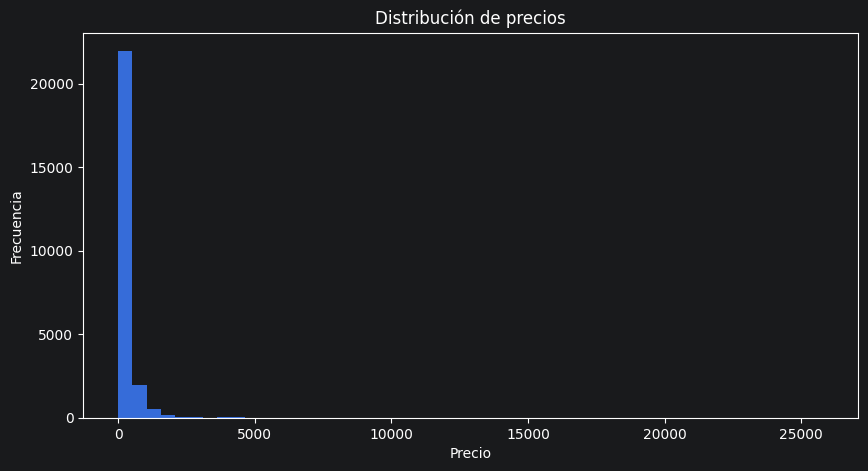

In [813]:
# Histograma de precios
plt.figure(figsize=(10, 5))
plt.hist(df['Precio'], bins=50)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

<Figure size 1000x500 with 0 Axes>

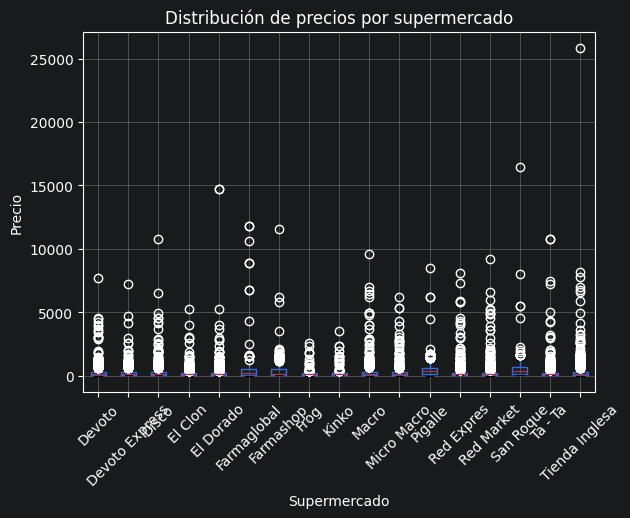

In [814]:
# Boxplot de precios por supermercado
plt.figure(figsize=(10, 5))
df.boxplot(column='Precio', by='Super', rot=45)
plt.title('Distribución de precios por supermercado')
plt.suptitle('')
plt.xlabel('Supermercado')
plt.ylabel('Precio')
plt.show()

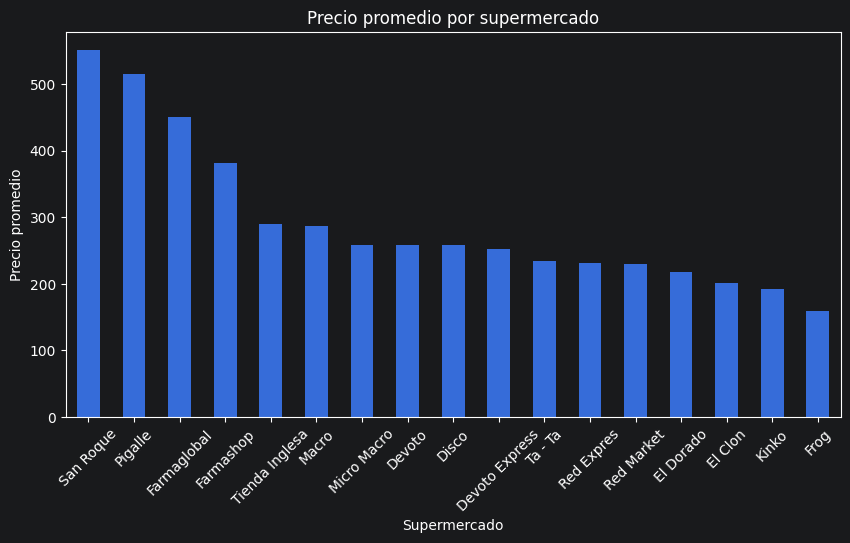

In [815]:
# Precio promedio por supermercado
precio_super = df.groupby('Super')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
precio_super.plot(kind='bar')
plt.title('Precio promedio por supermercado')
plt.xlabel('Supermercado')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45)
plt.show()

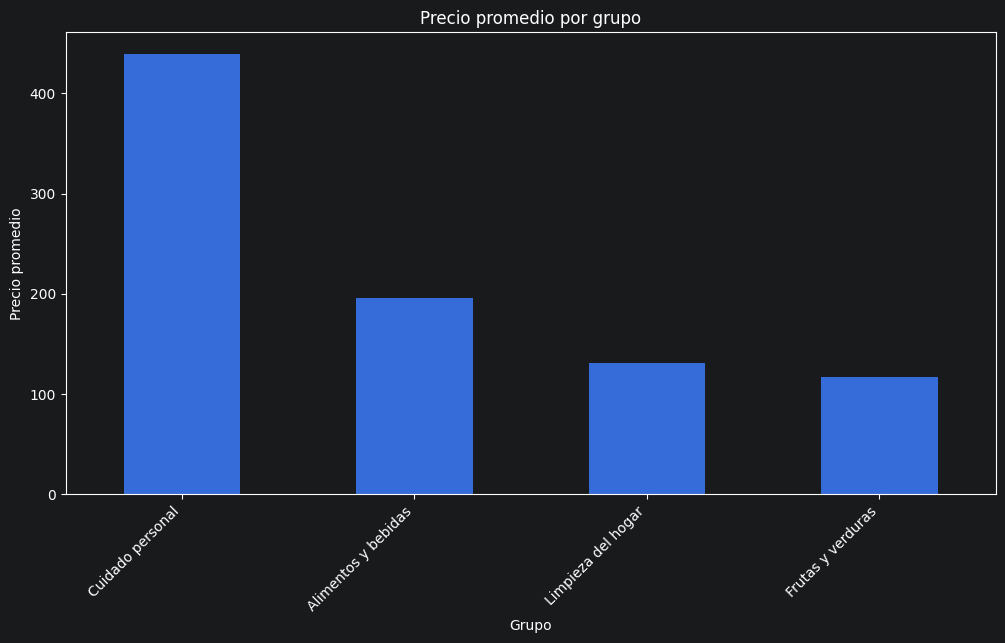

In [816]:
# Precio promedio por grupo
precio_grupo = df.groupby('Grupo')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
precio_grupo.plot(kind='bar')
plt.title('Precio promedio por grupo')
plt.xlabel('Grupo')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45, ha='right')
plt.show()

In [817]:
# Comparación supermercado vs grupo
tabla_super_grupo = pd.pivot_table(
    df,
    values='Precio',
    index='Grupo',
    columns='Super',
    aggfunc='mean'
)

tabla_super_grupo

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa
Grupo,,,,,,,,,,,,,,,,,
Alimentos y bebidas,225.83,206.62,197.47,160.68,146.76,268.35,161.13,160.46,203.13,244.53,249.48,NaN,165.66,192.75,269.00,199.43,230.85
Cuidado personal,415.84,435.61,482.15,300.75,426.24,520.41,517.58,197.12,195.37,474.74,377.90,526.52,397.58,382.54,579.08,431.18,484.47
Frutas y verduras,133.20,102.80,126.93,NaN,NaN,NaN,NaN,NaN,NaN,121.80,119.18,NaN,NaN,105.62,NaN,101.60,133.16
Limpieza del hogar,115.49,140.77,150.15,163.76,116.32,136.79,130.08,77.86,119.63,144.58,198.54,NaN,143.63,134.73,169.40,121.57,124.44


In [818]:
# Diferencia entre supermercados por producto
comparacion_productos = pd.pivot_table(
    df,
    values='Precio',
    index='Producto',
    columns='Super',
    aggfunc='mean'
)

comparacion_productos['diferencia_max_min'] = comparacion_productos.max(axis=1) - comparacion_productos.min(axis=1)

comparacion_productos.sort_values('diferencia_max_min', ascending=False).head(20)

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa,diferencia_max_min
Producto,,,,,,,,,,,,,,,,,,
protector solar spf 50 eucerin 150 ml.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,657.88",NaN,NaN,NaN,NaN,"7,224.00","5,566.12"
panales para ninos comun babysec (48 unidades),"1,133.00",NaN,"4,316.00",989.00,974.00,"1,184.50","4,628.00",NaN,NaN,"1,045.65",NaN,NaN,"1,017.00","1,060.00","1,104.00","1,085.00","1,157.00","3,654.00"
"crema facial revitalift filler dia, 50 ml.",NaN,NaN,NaN,NaN,"3,672.50","1,598.20","1,583.00",NaN,NaN,"1,593.65",NaN,NaN,NaN,NaN,NaN,839.00,"1,582.00","2,833.50"
protector solar spf 50 hawaiian tropic (240 ml.),"1,106.00",NaN,"1,106.00",NaN,NaN,"1,156.50","1,055.00",NaN,NaN,NaN,NaN,"1,055.00","1,058.00","3,680.00","1,030.00",NaN,"1,139.00","2,650.00"
chorizo suelto centenario-extra (1 kg.),"3,076.67",NaN,749.00,NaN,NaN,NaN,NaN,NaN,NaN,653.20,653.20,NaN,NaN,"2,060.00",NaN,639.00,654.50,"2,437.67"
perfume comun bebe & co. (120 ml.),676.00,NaN,676.00,NaN,NaN,738.95,681.00,NaN,NaN,735.70,794.50,655.00,640.50,599.00,745.00,"3,000.00",673.50,"2,401.00"
"pañales babysec premium extra extra grande, 48 us.","1,074.50","1,163.65","1,074.50",967.00,928.44,"2,961.28","1,174.00",NaN,NaN,"1,027.30",NaN,NaN,"1,033.30","1,057.65","1,123.00","2,753.58","1,091.00","2,032.83"
protector solar spf 40 dermaglós 250 ml.,NaN,NaN,NaN,NaN,NaN,NaN,"1,636.40",NaN,NaN,NaN,NaN,"1,374.30",NaN,NaN,"2,996.36",NaN,"1,708.40","1,622.06"
"pañales huggies primeros 100 dias pequeño, 40 us.",639.33,672.33,639.33,NaN,726.60,"2,189.06",736.90,NaN,NaN,"1,578.10","1,131.96",625.14,671.50,727.30,753.10,630.00,"1,232.73","1,563.92"


#### Observaciones

A partir de los gráficos de las variables categóricas, se pueden extraer las siguientes conclusiones:

- **Periodo**: El dataset contiene registros para los 12 meses de 2025. La distribución es bastante pareja entre meses, aunque `Dic25`, `Feb25`, `Ene25` y `Abr25` son los períodos con mayor cantidad de registros. `Jul25` es el período con menor cantidad.
- **Grupo**: La categoría con mayor presencia es `Alimentos y bebidas`, con una diferencia importante frente al resto. Le siguen `Cuidado personal`, `Limpieza del hogar` y `Frutas y verduras`.
- **Grupo**: Antes de normalizar los textos, algunas categorías aparecían duplicadas por diferencias de mayúsculas y minúsculas, por ejemplo `Alimentos y bebidas` y `alimentos y bebidas`. Esto fue corregido al estandarizar el texto.
- **Super**: Existen registros para varios supermercados. Los que tienen mayor cantidad de observaciones son `Red Expres`, `Tienda Inglesa`, `Red Market`, `Disco`, `Devoto` y `Ta - Ta`.
- **Super**: También se observa una cantidad importante de registros sin supermercado informado, por lo que esta variable tenía valores nulos relevantes.
- **Producto**: Es la variable categórica con mayor variedad de valores. Esto es esperable, ya que el dataset contiene muchos productos distintos.
- **Producto**: Debido a la gran cantidad de productos, no conviene analizar todos en un único gráfico de barras. Es más claro observar solo los productos más frecuentes, por ejemplo el top 10 o top 15.

#### Análisis de Variables Univariante Numéricas

Una **variable numérica** es un tipo de variable que puede tomar valores numéricos, como enteros, decimales o valores monetarios. Normalmente se representa utilizando un histograma, para observar su distribución, y un gráfico de caja o boxplot, para identificar valores atípicos.

En este dataset, la principal variable numérica es `Precio`, ya que representa el valor monetario registrado para cada producto en cada supermercado y período.

Sin embargo, antes de graficarla es necesario convertirla a formato numérico, porque originalmente aparece como texto y utiliza coma decimal, por ejemplo `80,00`.

Por lo tanto, la variable numérica a analizar será: `Precio`.

In [819]:
df["Precio"].describe()



count   24,736.00
mean       260.88
std        532.71
min          6.00
25%         75.00
50%        131.00
75%        275.00
max     25,800.00
Name: Precio, dtype: float64

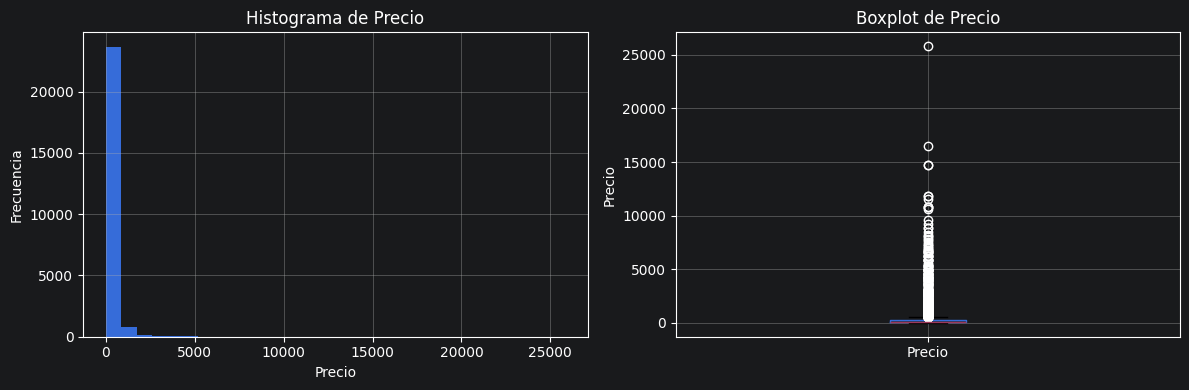

In [820]:
#Grafico

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Precio"].hist(ax=axes[0], bins=30)
axes[0].set_title("Histograma de Precio")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

df.boxplot(column="Precio", ax=axes[1])
axes[1].set_title("Boxplot de Precio")
axes[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()

#### Observaciones:
>
> - La combinación del histograma y el boxplot permite analizar la distribución de la variable `Precio` y detectar posibles valores atípicos.
> - La variable `Precio` presenta valores atípicos altos, ya que algunos registros tienen precios muy superiores al comportamiento general de los datos.
> - La distribución de `Precio` está sesgada hacia la derecha: la mayoría de los valores se concentran en precios bajos y medios, mientras que pocos registros presentan precios muy elevados.
> - La media de `Precio` es mayor que la mediana, lo que confirma que los valores altos influyen en el promedio.

### Análisis de Variables Multivariante

Tras analizar las variables una a una, es momento de estudiar cómo se relacionan entre sí. En este dataset no existe una variable objetivo o predictora como por ejemplo vimos en `Survived` en el caso del Titanic, por lo que el análisis multivariante se enfoca en entender cómo cambia la variable `Precio` según otras variables del dataset.

El objetivo principal es analizar si los precios varían según el `Grupo`, el `Producto`, el `Super` o el `Periodo`. Esto permite obtener conclusiones más claras sobre el comportamiento de los precios y tomar mejores decisiones sobre limpieza, eliminación de valores nulos u outliers.

Por ejemplo, la variable `Precio` presenta valores atípicos. Antes de eliminarlos, es importante revisar si estos outliers pertenecen a productos específicos, supermercados concretos o determinados grupos. Algunos precios altos podrían no ser errores, sino productos naturalmente más caros, como cremas, protectores solares o pañales.

Del mismo modo, la variable `Super` tiene una cantidad importante de valores nulos. Antes de eliminar esas filas, conviene analizar si esos registros tienen precios, productos o grupos relevantes, ya que podrían aportar información útil al análisis.

Por lo tanto, en este análisis multivariante se estudiará principalmente la relación entre `Precio` y las variables categóricas `Grupo`, `Producto`, `Super` y `Periodo`.

In [821]:
df.groupby("Grupo")["Precio"].describe()
df.groupby("Super")["Precio"].describe()
df.groupby("Periodo")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Periodo,,,,,,,,
Abr25,"2,123.00",274.39,658.36,6.00,76.00,133.00,275.00,"16,480.00"
Ago25,"2,056.00",237.12,358.07,6.00,75.00,130.81,269.00,"6,540.00"
Dic25,"2,140.00",265.37,490.83,24.90,76.00,134.96,285.00,"8,857.90"
Ene25,"2,113.00",250.77,457.13,6.00,74.00,129.00,270.00,"9,570.50"
Feb25,"2,108.00",287.02,800.60,24.00,75.00,129.90,280.00,"25,800.00"
Jul25,"1,794.00",243.61,380.50,24.90,76.00,131.00,267.62,"7,500.00"
Jun25,"1,915.00",264.84,572.63,21.00,75.00,131.00,265.50,"11,570.00"
Mar25,"2,089.00",266.63,551.54,6.00,75.00,129.90,269.85,"14,690.00"
May25,"2,117.00",248.90,425.35,6.00,75.00,132.87,269.00,"8,090.00"


In [822]:
#Para ver precios promedio por grupo:
df.groupby("Grupo")["Precio"].mean().sort_values(ascending=False)

Grupo
Cuidado personal      438.99
Alimentos y bebidas   196.14
Limpieza del hogar    130.93
Frutas y verduras     117.32
Name: Precio, dtype: float64

In [823]:
#Para ver precios promedio por supermercado:
df.groupby("Super")["Precio"].mean().sort_values(ascending=False)

Super
San Roque        550.51
Pigalle          515.06
Farmaglobal      449.90
Farmashop        381.19
Tienda Inglesa   290.10
Macro            286.77
Micro Macro      259.12
Devoto           258.45
Disco            257.80
Devoto Express   251.73
Ta - Ta          234.93
Red Expres       231.04
Red Market       229.94
El Dorado        217.61
El Clon          200.74
Kinko            192.20
Frog             159.21
Name: Precio, dtype: float64

In [824]:
#Para ver precios promedio por mes:
df.groupby("Periodo")["Precio"].mean().sort_values(ascending=False)

Periodo
Feb25   287.02
Abr25   274.39
Mar25   266.63
Oct25   266.42
Dic25   265.37
Jun25   264.84
Nov25   261.82
Sep25   260.88
Ene25   250.77
May25   248.90
Jul25   243.61
Ago25   237.12
Name: Precio, dtype: float64

#### Análisis numérico-numérico

Cuando las dos variables que se comparan tienen datos numéricos, se realiza un análisis numérico-numérico. Para comparar dos columnas numéricas se suelen utilizar diagramas de dispersión y análisis de correlaciones.

En este dataset, la única variable numérica relevante es `Precio`, ya que el resto de columnas (`Periodo`, `Grupo`, `Producto` y `Super`) son categóricas.

Por este motivo, no es posible realizar un análisis numérico-numérico tradicional entre dos variables del dataset. Tampoco tendría sentido calcular una matriz de correlación, ya que no existen dos o más variables numéricas para comparar entre sí.

En este caso, el análisis multivariante se enfocará principalmente en comparar la variable numérica `Precio` con variables categóricas como `Grupo`, `Super`, `Producto` y `Periodo`.


In [825]:
#Comprobarlo con código:
df.select_dtypes(include="number").columns

Index(['Precio'], dtype='str')

In [826]:
#Ver la correlación disponible:
df.select_dtypes(include="number").corr()
#Devuelve solo Precio, por eso no aporta mucho análisis.

,Precio
Precio,1.00


#### Análisis categórico-categórico

Cuando las dos variables que se comparan son categóricas, se realiza un análisis categórico-categórico. Este tipo de análisis permite observar cómo se distribuyen las categorías de una variable dentro de otra.

En este dataset, las variables categóricas principales son `Periodo`, `Grupo`, `Producto` y `Super`. Por lo tanto, se pueden analizar relaciones como:

- qué grupos de productos aparecen en cada período,
- qué supermercados tienen mayor cantidad de registros por grupo,
- qué productos aparecen con mayor frecuencia en cada supermercado,
- y cómo se distribuyen los grupos de productos entre los supermercados.

Para este análisis se pueden utilizar tablas de frecuencia, tablas cruzadas y gráficos de barras agrupadas o apiladas.

In [827]:
pd.crosstab(df["Grupo"], df["Super"])


Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa
Grupo,,,,,,,,,,,,,,,,,
Alimentos y bebidas,1156,954,1178,726,1078,30,181,562,397,1032,1000,0,1333,1266,11,1195,1196
Cuidado personal,435,375,439,327,438,602,493,119,53,412,286,352,615,514,395,364,609
Frutas y verduras,103,83,102,0,0,0,0,0,0,138,137,0,0,122,0,100,133
Limpieza del hogar,110,93,116,51,134,107,101,49,44,61,52,0,151,146,10,127,151


In [828]:
# Para verlo con porcentajes por fila:
pd.crosstab(df["Grupo"], df["Super"], normalize="index") * 100

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa
Grupo,,,,,,,,,,,,,,,,,
Alimentos y bebidas,8.69,7.18,8.86,5.46,8.11,0.23,1.36,4.23,2.99,7.76,7.52,0.00,10.03,9.52,0.08,8.99,9.00
Cuidado personal,6.37,5.49,6.43,4.79,6.41,8.82,7.22,1.74,0.78,6.03,4.19,5.16,9.01,7.53,5.79,5.33,8.92
Frutas y verduras,11.22,9.04,11.11,0.00,0.00,0.00,0.00,0.00,0.00,15.03,14.92,0.00,0.00,13.29,0.00,10.89,14.49
Limpieza del hogar,7.32,6.19,7.72,3.39,8.92,7.12,6.72,3.26,2.93,4.06,3.46,0.00,10.05,9.71,0.67,8.45,10.05


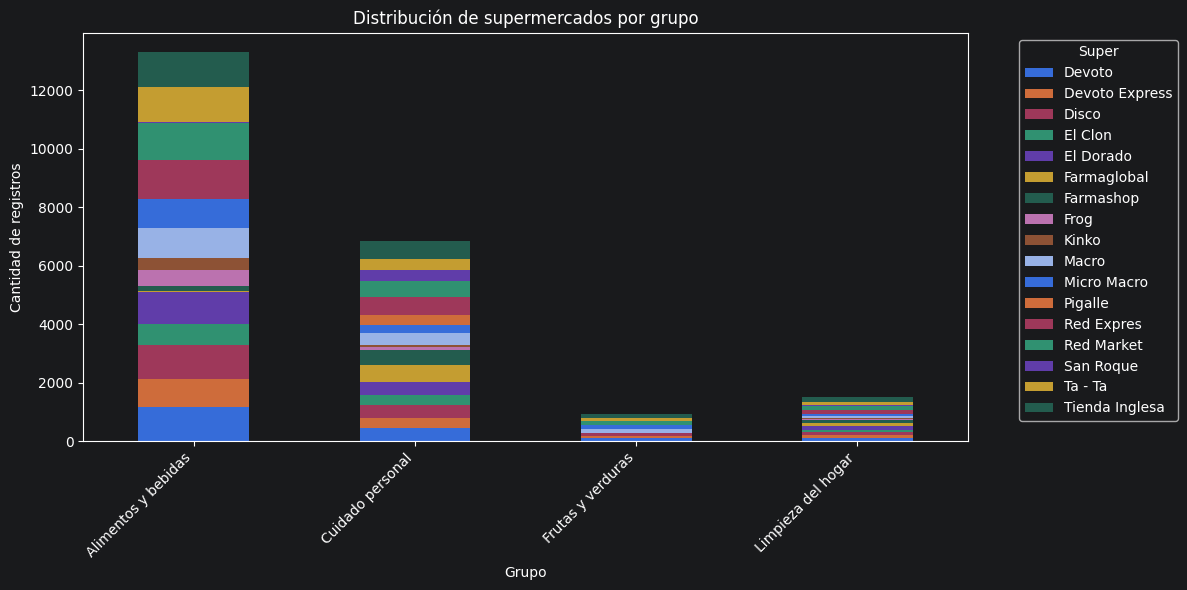

In [829]:
# Grafico:
tabla_grupo_super = pd.crosstab(df["Grupo"], df["Super"])

tabla_grupo_super.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribución de supermercados por grupo")
plt.xlabel("Grupo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Super", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [830]:
# Periodo vs Grupo:
pd.crosstab(df["Periodo"], df["Grupo"])

Grupo,Alimentos y bebidas,Cuidado personal,Frutas y verduras,Limpieza del hogar
Periodo,,,,
Abr25,1259,658,89,140
Ago25,1242,606,90,133
Dic25,1272,682,89,135
Ene25,1250,643,84,145
Feb25,1238,672,87,147
Jul25,1102,526,72,133
Jun25,1155,591,73,133
Mar25,1229,658,87,141
May25,1249,647,83,146


In [831]:
# Defino categorias
variables_categoricas = ["Periodo", "Grupo", "Producto", "Super"]

In [832]:
# Grupo vs Super
#Sirve para ver qué supermercados tienen más registros por tipo de producto.

pd.crosstab(df["Grupo"], df["Super"])

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa
Grupo,,,,,,,,,,,,,,,,,
Alimentos y bebidas,1156,954,1178,726,1078,30,181,562,397,1032,1000,0,1333,1266,11,1195,1196
Cuidado personal,435,375,439,327,438,602,493,119,53,412,286,352,615,514,395,364,609
Frutas y verduras,103,83,102,0,0,0,0,0,0,138,137,0,0,122,0,100,133
Limpieza del hogar,110,93,116,51,134,107,101,49,44,61,52,0,151,146,10,127,151


In [833]:
pd.crosstab(df["Grupo"], df["Super"], normalize="index") * 100

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa
Grupo,,,,,,,,,,,,,,,,,
Alimentos y bebidas,8.69,7.18,8.86,5.46,8.11,0.23,1.36,4.23,2.99,7.76,7.52,0.00,10.03,9.52,0.08,8.99,9.00
Cuidado personal,6.37,5.49,6.43,4.79,6.41,8.82,7.22,1.74,0.78,6.03,4.19,5.16,9.01,7.53,5.79,5.33,8.92
Frutas y verduras,11.22,9.04,11.11,0.00,0.00,0.00,0.00,0.00,0.00,15.03,14.92,0.00,0.00,13.29,0.00,10.89,14.49
Limpieza del hogar,7.32,6.19,7.72,3.39,8.92,7.12,6.72,3.26,2.93,4.06,3.46,0.00,10.05,9.71,0.67,8.45,10.05


In [834]:
# Periodo vs Grupo
# Sirve para ver si todos los grupos aparecen de forma pareja a lo largo de los meses.

pd.crosstab(df["Periodo"], df["Grupo"])

Grupo,Alimentos y bebidas,Cuidado personal,Frutas y verduras,Limpieza del hogar
Periodo,,,,
Abr25,1259,658,89,140
Ago25,1242,606,90,133
Dic25,1272,682,89,135
Ene25,1250,643,84,145
Feb25,1238,672,87,147
Jul25,1102,526,72,133
Jun25,1155,591,73,133
Mar25,1229,658,87,141
May25,1249,647,83,146


In [835]:
pd.crosstab(df["Periodo"], df["Grupo"], normalize="index") * 100

Grupo,Alimentos y bebidas,Cuidado personal,Frutas y verduras,Limpieza del hogar
Periodo,,,,
Abr25,58.67,30.66,4.15,6.52
Ago25,59.97,29.26,4.35,6.42
Dic25,58.40,31.31,4.09,6.20
Ene25,58.91,30.30,3.96,6.83
Feb25,57.74,31.34,4.06,6.86
Jul25,60.12,28.70,3.93,7.26
Jun25,59.17,30.28,3.74,6.81
Mar25,58.11,31.11,4.11,6.67
May25,58.78,30.45,3.91,6.87


In [836]:
# Periodo vs Super
# Sirve para ver si todos los supermercados fueron relevados en todos los períodos.

pd.crosstab(df["Periodo"], df["Super"])

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa
Periodo,,,,,,,,,,,,,,,,,
Abr25,151,154,161,96,140,63,62,59,41,139,127,32,187,172,39,150,180
Ago25,145,145,148,89,138,61,66,59,41,136,128,29,171,173,34,145,173
Dic25,153,154,154,95,138,67,73,72,42,140,124,31,179,168,32,151,176
Ene25,156,155,154,92,129,67,67,56,49,141,124,33,180,170,37,163,176
Feb25,153,151,153,90,136,65,65,61,45,140,129,31,174,177,35,149,183
Jul25,139,0,147,91,138,48,62,55,36,128,119,25,162,163,31,147,167
Jun25,159,0,160,96,142,60,61,60,41,130,113,27,166,179,34,140,167
Mar25,151,153,154,93,142,68,64,58,44,142,130,32,184,175,36,147,174
May25,150,151,156,91,140,62,63,57,43,140,124,31,176,176,37,147,173


In [837]:
# Super vs Producto
# Sirve para ver cuántos productos distintos tiene registrado cada supermercado.

df.groupby("Super")["Producto"].nunique().sort_values(ascending=False)

Super
Tienda Inglesa    340
Red Market        334
Red Expres        332
Ta - Ta           304
Disco             303
Devoto            298
El Dorado         271
Macro             266
Micro Macro       236
El Clon           182
Devoto Express    155
Farmashop         136
Frog              126
Farmaglobal       121
Kinko              84
San Roque          68
Pigalle            61
Name: Producto, dtype: int64

In [838]:
# Grupo vs Producto
# Sirve para ver cuántos productos distintos hay dentro de cada grupo.

df.groupby("Grupo")["Producto"].nunique().sort_values(ascending=False)

Grupo
Alimentos y bebidas    261
Cuidado personal       112
Frutas y verduras       29
Limpieza del hogar      24
Name: Producto, dtype: int64

In [839]:
# Producto vs Super
# Sirve para ver en cuántos supermercados aparece cada producto.

df.groupby("Producto")["Super"].nunique().sort_values(ascending=False).head(20)

Producto
desodorante en aerosol dove original envase 100 grs.            17
jabón de tocador dove blanco, 90 grs.                           17
desodorante en aerosol axe musk envase 113 grs.                 17
establecimientos relevados                                      17
jabón de tocador astral plata unidad 125 grs.                   17
desodorante en aerosol rexona active emotion envase 105 grs.    16
jabon de tocador en barra astral plata (unidad 125 grs.)        16
jabon de tocador en barra dove original (90 grs.)               16
desodorante aerosol dove original (envase 100 grs.)             16
talco xanapie aerosol, 175 ml.                                  15
tinta garnier nutrisse intense n.8.0, 1 unidad                  15
repelente aerosol off! larga duración,  170 cm3                 15
algodón zig zag cisne 100 gr.                                   15
champú fructis envase 350 ml.                                   15
repelente aerosol off! family aerosol,  170cm3       

In [840]:
# Combinaciones más frecuentes
# Sirve para detectar qué combinaciones de categorías aparecen más en el dataset.

df.groupby(["Grupo", "Super"]).size().sort_values(ascending=False).head(20)

Grupo                Super         
Alimentos y bebidas  Red Expres        1333
                     Red Market        1266
                     Tienda Inglesa    1196
                     Ta - Ta           1195
                     Disco             1178
                     Devoto            1156
                     El Dorado         1078
                     Macro             1032
                     Micro Macro       1000
                     Devoto Express     954
                     El Clon            726
Cuidado personal     Red Expres         615
                     Tienda Inglesa     609
                     Farmaglobal        602
Alimentos y bebidas  Frog               562
Cuidado personal     Red Market         514
                     Farmashop          493
                     Disco              439
                     El Dorado          438
                     Devoto             435
dtype: int64

In [841]:
df.groupby(["Periodo", "Grupo"]).size().sort_values(ascending=False).head(20)

Periodo  Grupo              
Dic25    Alimentos y bebidas    1272
Nov25    Alimentos y bebidas    1260
Abr25    Alimentos y bebidas    1259
Ene25    Alimentos y bebidas    1250
May25    Alimentos y bebidas    1249
Ago25    Alimentos y bebidas    1242
Oct25    Alimentos y bebidas    1238
Feb25    Alimentos y bebidas    1238
Mar25    Alimentos y bebidas    1229
Sep25    Alimentos y bebidas    1222
Jun25    Alimentos y bebidas    1155
Jul25    Alimentos y bebidas    1102
Dic25    Cuidado personal        682
Feb25    Cuidado personal        672
Mar25    Cuidado personal        658
Abr25    Cuidado personal        658
Oct25    Cuidado personal        651
May25    Cuidado personal        647
Ene25    Cuidado personal        643
Nov25    Cuidado personal        638
dtype: int64

In [842]:
df.groupby(["Producto", "Super"]).size().sort_values(ascending=False).head(20)

Producto                                                       Super         
desodorante en aerosol rexona active emotion envase 105 grs.   Red Market        14
cerveza patricia botella 960 ml.                               Micro Macro       14
jabón de tocador rexona unidad 125 grs.                        Ta - Ta           14
café envasado (no instantáneo) águila paquete 250 grs.         Ta - Ta           13
pasta dental kolynos triple acción unidad 90 grs.              Devoto            13
agua de mesa con gas nativa envase 2 lt.                       Disco             13
                                                               Devoto Express    13
papel higiénico hoja simple sin fin 4 rollos de 50 mts.        Tienda Inglesa    13
frankfurters cortos schneck paquete 8 us.                      Micro Macro       13
nalga vacuna sin hueso - sin marca 1 kg.                       Red Market        13
repelente aerosol off! larga duración,  170 cm3                Red Expres        1

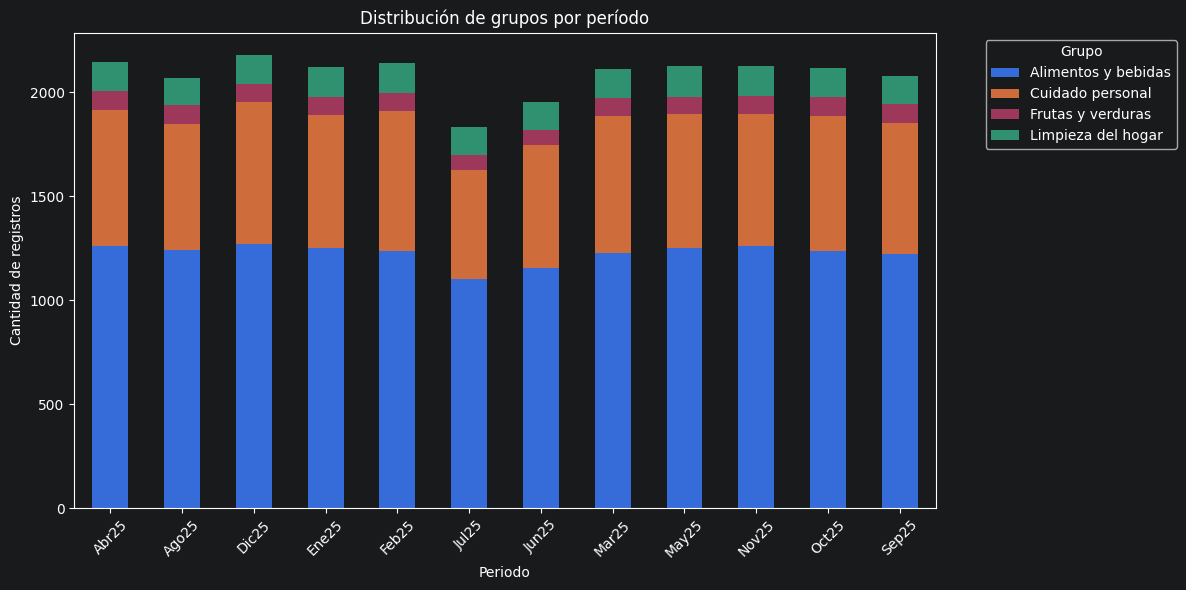

In [843]:
tabla = pd.crosstab(df["Periodo"], df["Grupo"])

tabla.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.title("Distribución de grupos por período")
plt.xlabel("Periodo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.legend(title="Grupo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

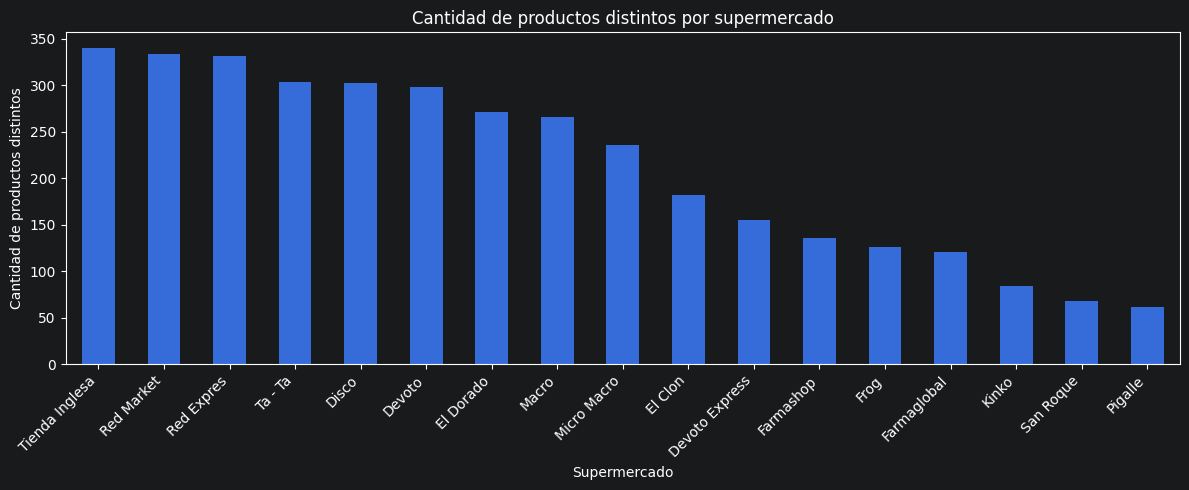

In [844]:
productos_por_super = df.groupby("Super")["Producto"].nunique().sort_values(ascending=False)

productos_por_super.plot(kind="bar", figsize=(12, 5))

plt.title("Cantidad de productos distintos por supermercado")
plt.xlabel("Supermercado")
plt.ylabel("Cantidad de productos distintos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [845]:
print("Productos distintos por grupo:")
print(df.groupby("Grupo")["Producto"].nunique().sort_values(ascending=False))

Productos distintos por grupo:
Grupo
Alimentos y bebidas    261
Cuidado personal       112
Frutas y verduras       29
Limpieza del hogar      24
Name: Producto, dtype: int64


In [846]:
print("Cantidad de registros por grupo:")
print(df["Grupo"].value_counts())

Cantidad de registros por grupo:
Grupo
Alimentos y bebidas    14716
Cuidado personal        7605
Limpieza del hogar      1669
Frutas y verduras       1020
Name: count, dtype: int64


In [847]:
print("Distribución de grupos por período:")
print(pd.crosstab(df["Periodo"], df["Grupo"]))

Distribución de grupos por período:
Grupo    Alimentos y bebidas  Cuidado personal  Frutas y verduras  \
Periodo                                                             
Abr25                   1259               658                 89   
Ago25                   1242               606                 90   
Dic25                   1272               682                 89   
Ene25                   1250               643                 84   
Feb25                   1238               672                 87   
Jul25                   1102               526                 72   
Jun25                   1155               591                 73   
Mar25                   1229               658                 87   
May25                   1249               647                 83   
Nov25                   1260               638                 87   
Oct25                   1238               651                 88   
Sep25                   1222               633                 91  

In [848]:
print("Productos distintos por supermercado:")
print(df.groupby("Super")["Producto"].nunique().sort_values(ascending=False))

Productos distintos por supermercado:
Super
Tienda Inglesa    340
Red Market        334
Red Expres        332
Ta - Ta           304
Disco             303
Devoto            298
El Dorado         271
Macro             266
Micro Macro       236
El Clon           182
Devoto Express    155
Farmashop         136
Frog              126
Farmaglobal       121
Kinko              84
San Roque          68
Pigalle            61
Name: Producto, dtype: int64


In [849]:
print("Productos que aparecen en más supermercados:")
print(df.groupby("Producto")["Super"].nunique().sort_values(ascending=False).head(20))

Productos que aparecen en más supermercados:
Producto
desodorante en aerosol dove original envase 100 grs.            17
jabón de tocador dove blanco, 90 grs.                           17
desodorante en aerosol axe musk envase 113 grs.                 17
establecimientos relevados                                      17
jabón de tocador astral plata unidad 125 grs.                   17
desodorante en aerosol rexona active emotion envase 105 grs.    16
jabon de tocador en barra astral plata (unidad 125 grs.)        16
jabon de tocador en barra dove original (90 grs.)               16
desodorante aerosol dove original (envase 100 grs.)             16
talco xanapie aerosol, 175 ml.                                  15
tinta garnier nutrisse intense n.8.0, 1 unidad                  15
repelente aerosol off! larga duración,  170 cm3                 15
algodón zig zag cisne 100 gr.                                   15
champú fructis envase 350 ml.                                   15
repelent

In [850]:
print("Combinaciones más frecuentes Grupo-Super:")
print(df.groupby(["Grupo", "Super"]).size().sort_values(ascending=False).head(20))

Combinaciones más frecuentes Grupo-Super:
Grupo                Super         
Alimentos y bebidas  Red Expres        1333
                     Red Market        1266
                     Tienda Inglesa    1196
                     Ta - Ta           1195
                     Disco             1178
                     Devoto            1156
                     El Dorado         1078
                     Macro             1032
                     Micro Macro       1000
                     Devoto Express     954
                     El Clon            726
Cuidado personal     Red Expres         615
                     Tienda Inglesa     609
                     Farmaglobal        602
Alimentos y bebidas  Frog               562
Cuidado personal     Red Market         514
                     Farmashop          493
                     Disco              439
                     El Dorado          438
                     Devoto             435
dtype: int64


In [851]:
print("Registros sin supermercado informado:")
print(df["Super"].isnull().sum())

Registros sin supermercado informado:
2483


##### Observaciones:

Del análisis categórico-categórico podemos obtener las siguientes conclusiones:

- `Alimentos y bebidas` es el grupo con mayor presencia en casi todos los cruces analizados. También es el grupo con mayor variedad de productos.
- `Cuidado personal` es el segundo grupo con mayor cantidad de registros y productos distintos.
- `Frutas y verduras` y `Limpieza del hogar` tienen una participación menor dentro del dataset.
- La distribución de grupos por período es bastante estable a lo largo del año. En todos los meses predominan los registros de `Alimentos y bebidas`, seguidos por `Cuidado personal`.
- Algunos períodos tienen menos registros que otros, especialmente `Jul25`, que presenta menor cantidad de observaciones en comparación con meses como `Dic25`, `Feb25` o `Ene25`.
- En cuanto a supermercados, `Tienda Inglesa`, `Red Market` y `Red Expres` son los que registran mayor variedad de productos distintos.
- Existen productos que aparecen en muchos supermercados, especialmente productos de cuidado personal como jabones y desodorantes. Esto indica que algunos productos están ampliamente distribuidos entre distintas cadenas.
- Las combinaciones más frecuentes se dan principalmente entre `Alimentos y bebidas` y supermercados como `Red Expres`, `Red Market`, `Tienda Inglesa`, `Ta - Ta`, `Disco` y `Devoto`.
- Luego de eliminar las categorías `Familia` y `Establecimientos relevados`, el análisis queda enfocado en los grupos principales de productos comparables.
-  Se observan **2.483 registros sin supermercado informado**, lo que puede afectar los análisis que comparan productos o grupos por cadena. Por este motivo, los resultados relacionados con `Super` deben interpretarse considerando esta ausencia de información.

##### Análisis de correlaciones

El análisis de correlaciones permite estudiar la relación entre variables numéricas. En un problema supervisado, normalmente se analiza la relación entre la variable objetivo y las variables predictoras. Sin embargo, en este dataset no existe una variable objetivo o target definida.

Además, el dataset cuenta con una única variable numérica principal: `Precio`. Las demás variables (`Periodo`, `Grupo`, `Producto` y `Super`) son categóricas.

Por este motivo, no es posible realizar un análisis de correlación tradicional entre múltiples variables numéricas. En su lugar, se puede estudiar cómo cambia el `Precio` según las categorías del dataset, por ejemplo comparando el precio promedio por `Grupo`, `Super`, `Producto` o `Periodo`.

Este análisis permite entender si ciertos grupos de productos, supermercados o períodos presentan precios más altos o más bajos.


In [852]:
df.select_dtypes(include="number").corr()

,Precio
Precio,1.00


In [853]:
df.groupby("Grupo")["Precio"].mean().sort_values(ascending=False)

Grupo
Cuidado personal      438.99
Alimentos y bebidas   196.14
Limpieza del hogar    130.93
Frutas y verduras     117.32
Name: Precio, dtype: float64

In [854]:
df.groupby("Super")["Precio"].mean().sort_values(ascending=False)

Super
San Roque        550.51
Pigalle          515.06
Farmaglobal      449.90
Farmashop        381.19
Tienda Inglesa   290.10
Macro            286.77
Micro Macro      259.12
Devoto           258.45
Disco            257.80
Devoto Express   251.73
Ta - Ta          234.93
Red Expres       231.04
Red Market       229.94
El Dorado        217.61
El Clon          200.74
Kinko            192.20
Frog             159.21
Name: Precio, dtype: float64

In [855]:
df.groupby("Periodo")["Precio"].mean().sort_values(ascending=False)

Periodo
Feb25   287.02
Abr25   274.39
Mar25   266.63
Oct25   266.42
Dic25   265.37
Jun25   264.84
Nov25   261.82
Sep25   260.88
Ene25   250.77
May25   248.90
Jul25   243.61
Ago25   237.12
Name: Precio, dtype: float64

#### Análisis numérico-categórico

El análisis numérico-categórico permite estudiar cómo se comporta una variable numérica según las categorías de otra variable. En este dataset, la variable numérica principal es `Precio`, mientras que las variables categóricas son `Periodo`, `Grupo`, `Producto` y `Super`.

Este análisis permite responder preguntas como:

- qué grupos de productos tienen precios más altos,
- qué supermercados presentan precios promedio más elevados,
- cómo varían los precios según el período,
- y qué productos concentran los precios más altos.

Para este tipo de análisis no se calculan correlaciones tradicionales, ya que las variables categóricas no son numéricas. En su lugar, se utilizan agrupaciones, medidas estadísticas y gráficos como boxplots o barras comparativas.

In [856]:
df.groupby("Grupo")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Grupo,,,,,,,,
Alimentos y bebidas,"14,475.00",196.14,336.90,21.00,72.00,115.00,198.00,"8,200.00"
Cuidado personal,"7,462.00",438.99,815.29,29.00,109.00,230.09,530.00,"25,800.00"
Frutas y verduras,"1,003.00",117.32,134.76,27.00,62.95,99.91,135.00,"1,469.00"
Limpieza del hogar,"1,641.00",130.93,166.05,30.00,73.00,90.00,151.00,"1,990.00"


In [857]:
df.groupby("Super")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Super,,,,,,,,
Devoto,"1,776.00",258.45,424.97,23.00,75.00,132.00,298.00,"7,710.00"
Devoto Express,"1,483.00",251.73,368.55,30.00,78.00,134.00,303.00,"7,230.00"
Disco,"1,807.00",257.80,473.54,29.00,75.00,129.00,293.00,"10,790.00"
El Clon,"1,087.00",200.74,324.62,16.00,75.00,125.00,189.00,"5,290.00"
El Dorado,"1,627.00",217.61,601.44,21.00,69.00,112.00,192.50,"14,690.00"
Farmaglobal,731.00,449.90,980.16,10.00,100.11,197.07,539.49,"11,845.10"
Farmashop,770.00,381.19,638.08,33.00,84.00,179.00,527.00,"11,570.00"
Frog,724.00,159.21,202.27,22.00,69.00,110.00,191.25,"2,560.00"
Kinko,493.00,192.20,296.32,28.00,87.00,120.00,195.00,"3,550.00"


In [858]:
df.groupby("Periodo")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Periodo,,,,,,,,
Abr25,"2,123.00",274.39,658.36,6.00,76.00,133.00,275.00,"16,480.00"
Ago25,"2,056.00",237.12,358.07,6.00,75.00,130.81,269.00,"6,540.00"
Dic25,"2,140.00",265.37,490.83,24.90,76.00,134.96,285.00,"8,857.90"
Ene25,"2,113.00",250.77,457.13,6.00,74.00,129.00,270.00,"9,570.50"
Feb25,"2,108.00",287.02,800.60,24.00,75.00,129.90,280.00,"25,800.00"
Jul25,"1,794.00",243.61,380.50,24.90,76.00,131.00,267.62,"7,500.00"
Jun25,"1,915.00",264.84,572.63,21.00,75.00,131.00,265.50,"11,570.00"
Mar25,"2,089.00",266.63,551.54,6.00,75.00,129.90,269.85,"14,690.00"
May25,"2,117.00",248.90,425.35,6.00,75.00,132.87,269.00,"8,090.00"


In [859]:
# Precio promedio por grupo:
df.groupby("Grupo")["Precio"].mean().sort_values(ascending=False)

Grupo
Cuidado personal      438.99
Alimentos y bebidas   196.14
Limpieza del hogar    130.93
Frutas y verduras     117.32
Name: Precio, dtype: float64

In [860]:
#Precio promedio por supermercado:
df.groupby("Super")["Precio"].mean().sort_values(ascending=False)

Super
San Roque        550.51
Pigalle          515.06
Farmaglobal      449.90
Farmashop        381.19
Tienda Inglesa   290.10
Macro            286.77
Micro Macro      259.12
Devoto           258.45
Disco            257.80
Devoto Express   251.73
Ta - Ta          234.93
Red Expres       231.04
Red Market       229.94
El Dorado        217.61
El Clon          200.74
Kinko            192.20
Frog             159.21
Name: Precio, dtype: float64

In [861]:
#Precio promedio por período:
df.groupby("Periodo")["Precio"].mean().sort_values(ascending=False)

Periodo
Feb25   287.02
Abr25   274.39
Mar25   266.63
Oct25   266.42
Dic25   265.37
Jun25   264.84
Nov25   261.82
Sep25   260.88
Ene25   250.77
May25   248.90
Jul25   243.61
Ago25   237.12
Name: Precio, dtype: float64

<Figure size 1000x500 with 0 Axes>

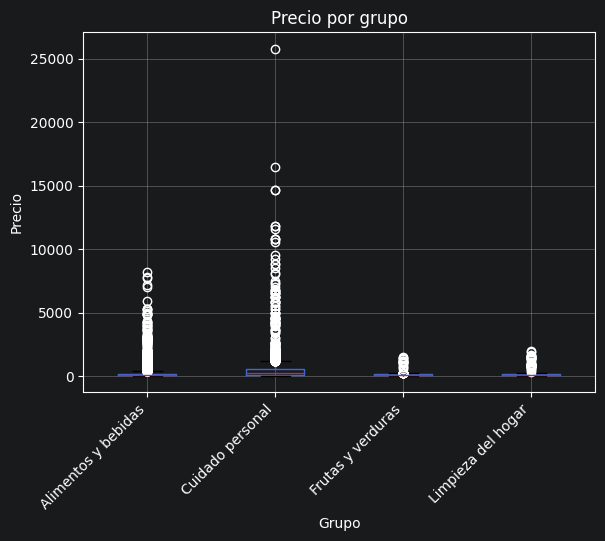

In [862]:
# Boxplot de precio por grupo:

plt.figure(figsize=(10, 5))
df.boxplot(column="Precio", by="Grupo")
plt.title("Precio por grupo")
plt.suptitle("")
plt.xlabel("Grupo")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

<Figure size 1200x500 with 0 Axes>

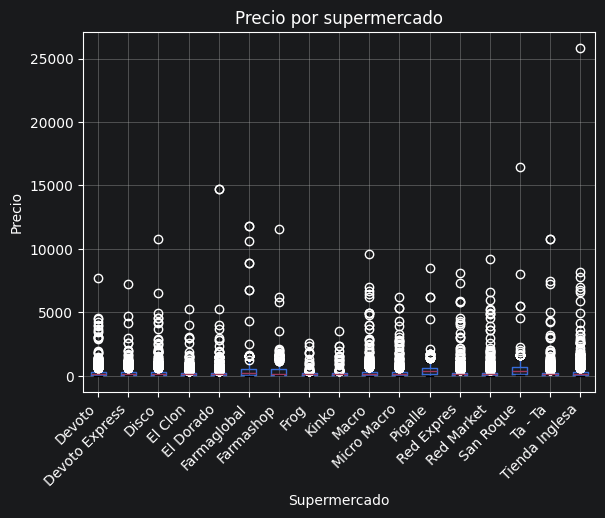

In [863]:
#Boxplot de precio por supermercado:

plt.figure(figsize=(12, 5))
df.boxplot(column="Precio", by="Super")
plt.title("Precio por supermercado")
plt.suptitle("")
plt.xlabel("Supermercado")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

In [864]:
# Estadísticas de Precio por Grupo
analisis_grupo = df.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)

analisis_grupo

,cantidad,minimo,mediana,promedio,maximo
Grupo,,,,,
Cuidado personal,7462,29.00,230.09,438.99,"25,800.00"
Alimentos y bebidas,14475,21.00,115.00,196.14,"8,200.00"
Limpieza del hogar,1641,30.00,90.00,130.93,"1,990.00"
Frutas y verduras,1003,27.00,99.91,117.32,"1,469.00"


In [865]:
# Estadísticas de Precio por Supermercado
analisis_super = df.groupby("Super")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)

analisis_super

,cantidad,minimo,mediana,promedio,maximo
Super,,,,,
San Roque,416,32.00,355.00,550.51,"16,480.00"
Pigalle,355,18.00,365.00,515.06,"8,490.00"
Farmaglobal,731,10.00,197.07,449.90,"11,845.10"
Farmashop,770,33.00,179.00,381.19,"11,570.00"
Tienda Inglesa,2059,19.00,134.00,290.10,"25,800.00"
Macro,1626,8.00,134.96,286.77,"9,570.50"
Micro Macro,1449,7.00,134.16,259.12,"6,210.00"
Devoto,1776,23.00,132.00,258.45,"7,710.00"
Disco,1807,29.00,129.00,257.80,"10,790.00"


In [866]:
# Estadísticas de Precio por Periodo
analisis_periodo = df.groupby("Periodo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("promedio", ascending=False)

analisis_periodo

,cantidad,minimo,mediana,promedio,maximo
Periodo,,,,,
Feb25,2108,24.00,129.90,287.02,"25,800.00"
Abr25,2123,6.00,133.00,274.39,"16,480.00"
Mar25,2089,6.00,129.90,266.63,"14,690.00"
Oct25,2104,6.00,133.00,266.42,"14,690.00"
Dic25,2140,24.90,134.96,265.37,"8,857.90"
Jun25,1915,21.00,131.00,264.84,"11,570.00"
Nov25,2112,6.00,134.00,261.82,"7,800.00"
Sep25,2065,6.00,132.00,260.88,"11,845.10"
Ene25,2113,6.00,129.00,250.77,"9,570.50"


In [867]:
# Productos con precios más altos
productos_mas_caros = df.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("maximo", ascending=False)

productos_mas_caros.head(20)

,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,
protector solar spf 50 eucerin 150 ml.,10,"1,473.50","2,580.00","4,533.15","25,800.00"
protector solar spf 40 dermaglós 250 ml.,46,949.00,"1,649.00","1,926.04","16,480.00"
"crema facial revitalift filler dia, 50 ml.",28,839.00,"1,588.33","2,454.56","14,690.00"
"pañales babysec premium extra extra grande, 48 us.",153,539.00,"1,079.00","1,347.12","11,845.10"
panales para ninos comun babysec (48 unidades),29,949.00,"1,085.00","1,782.18","11,570.00"
protector solar spf 20 dermaglós 250 ml.,52,849.00,"1,333.50","1,550.98","10,592.30"
protector solar spf 80 hawaiian tropic 240 ml.,121,617.00,"1,055.00","1,103.77","9,570.50"
protector solar spf 50 hawaiian tropic (240 ml.),20,920.00,"1,058.00","1,463.75","9,200.00"
"pañales huggies primeros 100 dias pequeño, 40 us.",123,571.00,673.00,"1,015.03","8,857.90"


In [868]:
# Productos con mayor mediana de precio
productos_mayor_mediana = df.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("mediana", ascending=False)

productos_mayor_mediana.head(20)

,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,
protector solar spf 50 eucerin 150 ml.,10,"1,473.50","2,580.00","4,533.15","25,800.00"
protector solar spf 40 dermaglos (250 ml.),10,"1,648.00","1,748.00","1,709.70","1,749.00"
protector solar spf 40 dermaglós 250 ml.,46,949.00,"1,649.00","1,926.04","16,480.00"
"crema facial revitalift filler dia, 50 ml.",28,839.00,"1,588.33","2,454.56","14,690.00"
crema facial revitalift (50 ml.),5,"1,469.00","1,469.00","1,520.20","1,597.00"
protector solar spf 20 dermaglos (250 ml.),10,"1,059.20","1,356.00","1,305.34","1,415.00"
protector solar spf 20 dermaglós 250 ml.,52,849.00,"1,333.50","1,550.98","10,592.30"
protector solar spf 30 hawaiian tropic 180 ml.,65,951.30,"1,107.00","1,062.40","1,216.02"
panales para ninos comun babysec (48 unidades),29,949.00,"1,085.00","1,782.18","11,570.00"


##### Observaciones:

- Existe una relación clara entre `Grupo` y `Precio`. El grupo `Cuidado personal` presenta los precios más altos en promedio y mediana, especialmente por productos como protectores solares, pañales, cremas y tintas.
- `Alimentos y bebidas` es el grupo con mayor cantidad de registros, pero sus precios tienden a ser más bajos que los de `Cuidado personal`.
- `Limpieza del hogar` y `Frutas y verduras` presentan precios más bajos y una menor dispersión en comparación con los otros grupos.
- También se observan diferencias entre supermercados. Algunos como `San Roque`, `Pigalle`, `FarmaGlobal` y `Farmashop` muestran precios promedio más altos, lo cual puede estar relacionado con que venden más productos de cuidado personal o farmacia.
- El análisis por `Periodo` muestra que los precios promedio varían entre meses, aunque la diferencia no es tan fuerte como la observada entre grupos o supermercados.
- Los valores máximos de `Precio` afectan mucho los promedios, por lo que conviene comparar también la mediana. Esto permite reducir el efecto de los outliers.
- Al quitar outliers, las diferencias entre grupos y supermercados siguen existiendo, pero se vuelven menos extremas.
- Los productos con precios más altos pertenecen principalmente a categorías como pañales, protectores solares, tintas y cremas, por lo que no todos los outliers necesariamente son errores.

## Paso 6: Ingeniería de características

### Ingeniería de características

La **ingeniería de características** (*feature engineering*) es un proceso que implica crear nuevas variables a partir de las existentes, transformar datos o corregir formatos para mejorar el análisis y facilitar posibles modelos posteriores.

En los pasos previos ya se realizaron algunas tareas relacionadas con este proceso, como la eliminación de duplicados, el tratamiento de valores nulos, la normalización de textos y la conversión de la variable `Precio` a formato numérico.

En este dataset no existe una variable objetivo o *target* definida, por lo que la ingeniería de características se enfoca principalmente en mejorar la calidad de los datos y generar nuevas variables que permitan analizar mejor el comportamiento de los precios.

Algunas transformaciones útiles para este dataset son:

- convertir `Precio` a formato numérico,
- normalizar las variables categóricas (`Grupo`, `Producto`, `Super`),
- crear una variable de mes a partir de `Periodo`,
- crear una variable que indique si un precio es outlier,
- crear rangos de precio para clasificar productos en baratos, medios o caros,
- y calcular precios promedio por producto o supermercado.


In [869]:
# Crear indicador de outlier:
Q1 = df.groupby("Producto")["Precio"].transform(lambda x: x.quantile(0.25))
Q3 = df.groupby("Producto")["Precio"].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

df["Limite_superior_producto"] = Q3 + 1.5 * IQR
df["Es_outlier_producto"] = df["Precio"] > df["Limite_superior_producto"]

df_outliers_producto = df[df["Es_outlier_producto"]].copy()

df_outliers_producto.sort_values("Precio", ascending=False)

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto
25064,Feb25,Cuidado personal,protector solar spf 50 eucerin 150 ml.,Tienda Inglesa,"25,800.00","3,884.25",True
24583,Abr25,Cuidado personal,protector solar spf 40 dermaglós 250 ml.,San Roque,"16,480.00","1,898.00",True
25053,Oct25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True
24685,Mar25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True
25168,Abr25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Farmaglobal,"11,845.10","1,306.51",True
...,...,...,...,...,...,...,...
20017,Sep25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True
2082,Ago25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True
3895,Dic25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True
18186,Oct25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True


In [870]:
Q1 = df.groupby("Producto")["Precio"].transform(lambda x: x.quantile(0.25))
Q2 = df.groupby("Producto")["Precio"].transform(lambda x: x.quantile(0.50))
Q3 = df.groupby("Producto")["Precio"].transform(lambda x: x.quantile(0.75))

df["Rango_precio_producto"] = pd.Series(index=df.index, dtype="object")

df.loc[df["Precio"] <= Q1, "Rango_precio_producto"] = "Bajo"
df.loc[(df["Precio"] > Q1) & (df["Precio"] <= Q2), "Rango_precio_producto"] = "Medio bajo"
df.loc[(df["Precio"] > Q2) & (df["Precio"] <= Q3), "Rango_precio_producto"] = "Medio alto"
df.loc[df["Precio"] > Q3, "Rango_precio_producto"] = "Alto"

In [871]:
df[["Producto", "Super", "Precio", "Rango_precio_producto"]].sort_values(
    ["Producto", "Precio"]
)

,Producto,Super,Precio,Rango_precio_producto
14269,aceite de girasol marca propia envase 900 cc,Disco,79.00,Bajo
16110,aceite de girasol marca propia envase 900 cc,Devoto,79.00,Bajo
16111,aceite de girasol marca propia envase 900 cc,Devoto Express,79.00,Bajo
16112,aceite de girasol marca propia envase 900 cc,Disco,79.00,Bajo
23951,aceite de girasol marca propia envase 900 cc,NaN,79.00,Bajo
...,...,...,...,...
15969,"zapallo criollo, 1 kg.",Tienda Inglesa,73.00,Medio alto
17810,"zapallo criollo, 1 kg.",Tienda Inglesa,73.00,Medio alto
19648,"zapallo criollo, 1 kg.",Tienda Inglesa,73.00,Medio alto
21469,"zapallo criollo, 1 kg.",Tienda Inglesa,73.00,Medio alto


In [872]:
# Crear mes desde `Periodo`:
mapa_meses = {
    "Ene25": 1,
    "Feb25": 2,
    "Mar25": 3,
    "Abr25": 4,
    "May25": 5,
    "Jun25": 6,
    "Jul25": 7,
    "Ago25": 8,
    "Sep25": 9,
    "Oct25": 10,
    "Nov25": 11,
    "Dic25": 12
}

df["Mes"] = df["Periodo"].map(mapa_meses)

In [873]:
df["Periodo"].unique()

<ArrowStringArray>
['Abr25', 'Ago25', 'Dic25', 'Ene25', 'Feb25', 'Jul25', 'Jun25', 'Mar25',
 'May25', 'Nov25', 'Oct25', 'Sep25']
Length: 12, dtype: str

In [874]:
df["Mes"].isnull().sum()

np.int64(0)

#### Análisis de outliers

**Intro to outliers**

Un **valor atípico** (*outlier*) es un dato que se aleja significativamente del comportamiento general del conjunto de datos.

En este dataset, el análisis de outliers se concentra principalmente en la variable `Precio`, ya que es la única variable numérica relevante. Los valores atípicos en precios pueden deberse a:

- errores de carga,
- diferencias reales entre tipos de productos,
- productos naturalmente más caros,
- promociones o precios especiales,
- o diferencias entre supermercados.

Para tratar los outliers existen varias estrategias:

- **Eliminarlos**: se eliminan las filas con precios atípicos. Esta opción puede ser útil si se confirma que son errores o si distorsionan mucho el análisis.
- **Mantenerlos**: se conservan porque pueden representar productos realmente caros o información importante.
- **Reemplazarlos**: se sustituyen por otro valor, como la mediana o un límite máximo, para reducir su efecto sin eliminar filas completas.

En este caso, antes de decidir qué hacer con los outliers, es importante analizarlos por `Grupo`, `Producto`, `Super` y `Periodo`.

**Outliers: Análisis descriptivo**

El análisis descriptivo permite caracterizar la variable `Precio` mediante medidas como la media, mediana, desviación estándar, mínimo, máximo y cuartiles.

La función `.describe()` de pandas permite obtener rápidamente estos indicadores y detectar si existen valores extremos. Si la media es mucho mayor que la mediana, esto puede indicar una distribución sesgada hacia precios altos.

In [875]:
df["Precio"].describe()

count   24,736.00
mean       260.88
std        532.71
min          6.00
25%         75.00
50%        131.00
75%        275.00
max     25,800.00
Name: Precio, dtype: float64

In [876]:
#Para ver media y mediana juntas:

print("Media:", df["Precio"].mean())
print("Mediana:", df["Precio"].median())
print("Máximo:", df["Precio"].max())

Media: 260.8830975097025
Mediana: 131.0
Máximo: 25800.0


In [877]:
# Ya formule IQR y tengo limite superior, creo inferior
limite_inferior = Q1 - 1.5 * IQR
limite_inferior, limite_superior

(0        57.75
 1        57.75
 2        57.75
 3        57.75
 4        57.75
          ...  
 25164    50.00
 25165   453.00
 25166   123.00
 25167    83.75
 25168   889.15
 Name: Precio, Length: 25169, dtype: float64,
 0         123.75
 1         123.75
 2         123.75
 3         123.75
 4         123.75
           ...   
 25164     162.00
 25165     901.00
 25166     187.00
 25167     124.15
 25168   1,306.51
 Name: Precio, Length: 25169, dtype: float64)

In [878]:
# Para guardar los outliers:
df_outliers = df[
    (df["Precio"] < limite_inferior) |
    (df["Precio"] > limite_superior)
].copy()

df_outliers

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes
28,Abr25,Alimentos y bebidas,aceite de girasol óptimo envase 900 cc,Frog,123.00,108.00,True,Alto,4
65,Abr25,Alimentos y bebidas,aceite de soja condesa envase 900 cc,Tienda Inglesa,88.00,85.50,True,Alto,4
95,Abr25,Alimentos y bebidas,agua de mesa con gas nativa envase 2 lt.,Frog,68.00,79.00,False,Bajo,4
161,Abr25,Alimentos y bebidas,"agua mineral sin gas(bidón) salus 6,25lts",Red Expres,125.00,154.50,False,Bajo,4
232,Abr25,Alimentos y bebidas,arvejas en conserva cololó lata 380 grs.,Red Market,29.50,58.68,False,Bajo,4
...,...,...,...,...,...,...,...,...,...
25164,Dic25,Cuidado personal,"afeitadora xtreme3 piel delicada x1, 1 unidad",Devoto Express,"1,010.00",162.00,True,Alto,12
25165,Mar25,Cuidado personal,"perfume delice candy, 50 ml.",Farmashop,"6,210.00",901.00,True,Alto,3
25166,Feb25,Cuidado personal,"toallitas femeninas ladysoft basica, 16 us.",Tienda Inglesa,"1,780.00",187.00,True,Alto,2
25167,Dic25,Frutas y verduras,"papa blanca, 1 kg.",Disco,"1,090.00",124.15,True,Alto,12


In [879]:
#Para resumirlos:
df_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("cantidad", ascending=False)

,cantidad,minimo,mediana,promedio,maximo
Grupo,,,,,
Alimentos y bebidas,1109,24.00,181.00,637.67,"8,200.00"
Cuidado personal,558,30.00,401.12,"1,411.72","25,800.00"
Limpieza del hogar,109,40.00,179.00,470.16,"1,990.00"
Frutas y verduras,101,32.00,81.00,245.30,"1,469.00"


In [880]:
df_outliers.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("maximo", ascending=False).head(20)

,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,
protector solar spf 50 eucerin 150 ml.,1,"25,800.00","25,800.00","25,800.00","25,800.00"
protector solar spf 40 dermaglós 250 ml.,6,949.00,"1,019.50","3,596.17","16,480.00"
"crema facial revitalift filler dia, 50 ml.",3,839.00,"14,690.00","10,073.00","14,690.00"
"pañales babysec premium extra extra grande, 48 us.",10,539.00,"1,454.00","5,033.42","11,845.10"
panales para ninos comun babysec (48 unidades),2,"10,790.00","11,180.00","11,180.00","11,570.00"
protector solar spf 20 dermaglós 250 ml.,2,"8,490.00","9,541.15","9,541.15","10,592.30"
protector solar spf 80 hawaiian tropic 240 ml.,13,617.00,617.00,"1,375.88","9,570.50"
protector solar spf 50 hawaiian tropic (240 ml.),4,920.00,920.00,"2,990.00","9,200.00"
"pañales huggies primeros 100 dias pequeño, 40 us.",6,"6,210.00","6,607.80","7,225.23","8,857.90"


In [881]:
#Como el precio no es negativo, me enfoco en los superiores:
df_outliers = df[df["Precio"] > limite_superior].copy()

In [882]:
df_outliers.sort_values("Precio", ascending=False).head(20)

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes
25064,Feb25,Cuidado personal,protector solar spf 50 eucerin 150 ml.,Tienda Inglesa,"25,800.00","3,884.25",True,Alto,2
24583,Abr25,Cuidado personal,protector solar spf 40 dermaglós 250 ml.,San Roque,"16,480.00","1,898.00",True,Alto,4
25053,Oct25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,10
24685,Mar25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,3
25168,Abr25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Farmaglobal,"11,845.10","1,306.51",True,Alto,4
24846,Sep25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Farmaglobal,"11,845.10","1,306.51",True,Alto,9
24781,Jun25,Cuidado personal,panales para ninos comun babysec (48 unidades),Farmashop,"11,570.00","1,334.00",True,Alto,6
24816,Jun25,Cuidado personal,panales para ninos comun babysec (48 unidades),Disco,"10,790.00","1,334.00",True,Alto,6
24728,Abr25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Ta - Ta,"10,790.00","1,306.51",True,Alto,4
24964,Feb25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Ta - Ta,"10,790.00","1,306.51",True,Alto,2


In [883]:
df.sort_values("Precio", ascending=False).head(10)

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes
25064,Feb25,Cuidado personal,protector solar spf 50 eucerin 150 ml.,Tienda Inglesa,"25,800.00","3,884.25",True,Alto,2
24583,Abr25,Cuidado personal,protector solar spf 40 dermaglós 250 ml.,San Roque,"16,480.00","1,898.00",True,Alto,4
24685,Mar25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,3
25053,Oct25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,10
24846,Sep25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Farmaglobal,"11,845.10","1,306.51",True,Alto,9
25168,Abr25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Farmaglobal,"11,845.10","1,306.51",True,Alto,4
24781,Jun25,Cuidado personal,panales para ninos comun babysec (48 unidades),Farmashop,"11,570.00","1,334.00",True,Alto,6
24964,Feb25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Ta - Ta,"10,790.00","1,306.51",True,Alto,2
24728,Abr25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Ta - Ta,"10,790.00","1,306.51",True,Alto,4
24816,Jun25,Cuidado personal,panales para ninos comun babysec (48 unidades),Disco,"10,790.00","1,334.00",True,Alto,6


In [884]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Precio,"24,736.00",260.88,532.71,6.00,75.00,131.00,275.00,"25,800.00"
Limite_superior_producto,"25,169.00",270.38,297.13,36.01,91.50,156.50,317.50,"3,884.25"
Mes,"25,169.00",6.50,3.49,1.00,3.00,6.00,10.00,12.00


Si bien la experiencia es un componente importante en el análisis de los resultados de la tabla anterior, podemos utilizar ciertas reglas para detectar valores atípicos, como observar el valor mínimo y máximo de una variable y compararlo con sus percentiles 25%, 50% y 75%.

> Observaciones
>
> La columna `Precio` tiene una media aproximada de **238,65**, una mediana o percentil 50% de **129**, y un valor máximo de **25.800**.
>
> Esta diferencia indica que existen precios muy altos en comparación con la mayoría de los registros. Como la media es bastante mayor que la mediana, la distribución está sesgada hacia la derecha.
>
> El valor máximo de **25.800** podría parecer un valor atípico o incluso un posible error de carga. Sin embargo, también podría corresponder a un producto efectivamente caro, suena a que es muy caro para que lo sea, pero debemos de investigar.
>
> Por este motivo, antes de eliminarlo, decidimos analizar a qué `Producto`, `Grupo`, `Super` y `Periodo` pertenece ese registro.


In [885]:
df_outliers_superiores = df[df["Precio"] > limite_superior].copy()

df_outliers_superiores.sort_values("Precio", ascending=False)

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes
25064,Feb25,Cuidado personal,protector solar spf 50 eucerin 150 ml.,Tienda Inglesa,"25,800.00","3,884.25",True,Alto,2
24583,Abr25,Cuidado personal,protector solar spf 40 dermaglós 250 ml.,San Roque,"16,480.00","1,898.00",True,Alto,4
25053,Oct25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,10
24685,Mar25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,3
25168,Abr25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Farmaglobal,"11,845.10","1,306.51",True,Alto,4
...,...,...,...,...,...,...,...,...,...
20017,Sep25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,9
2082,Ago25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,8
3895,Dic25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,12
18186,Oct25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,10


In [886]:
df_outliers_superiores = df_outliers_superiores.sort_values(
    "Precio",
    ascending=False
).reset_index(drop=True)

df_outliers_superiores

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes
0,Feb25,Cuidado personal,protector solar spf 50 eucerin 150 ml.,Tienda Inglesa,"25,800.00","3,884.25",True,Alto,2
1,Abr25,Cuidado personal,protector solar spf 40 dermaglós 250 ml.,San Roque,"16,480.00","1,898.00",True,Alto,4
2,Oct25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,10
3,Mar25,Cuidado personal,"crema facial revitalift filler dia, 50 ml.",El Dorado,"14,690.00","1,789.00",True,Alto,3
4,Abr25,Cuidado personal,"pañales babysec premium extra extra grande, 48...",Farmaglobal,"11,845.10","1,306.51",True,Alto,4
...,...,...,...,...,...,...,...,...,...
1139,Sep25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,9
1140,Ago25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,8
1141,Dic25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,12
1142,Oct25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Ta - Ta,47.00,36.96,True,Alto,10


**Outliers: Visualización**

Dibujar un diagrama de caja de la variable `Precio` permite identificar visualmente los valores atípicos. En este tipo de gráfico, los puntos que quedan alejados del cuerpo principal de la caja representan precios que se salen del rango esperado según la distribución de los datos.

En este dataset, el boxplot es especialmente útil porque `Precio` presenta valores muy altos en comparación con la mayoría de los registros. Estos valores pueden corresponder a errores de carga o a productos naturalmente más caros.


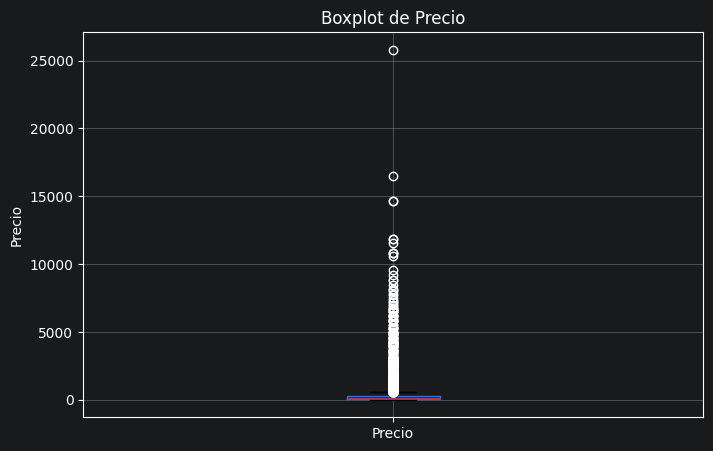

In [887]:
plt.figure(figsize=(8, 5))
df.boxplot(column="Precio")

plt.title("Boxplot de Precio")
plt.ylabel("Precio")
plt.show()

<Figure size 1000x500 with 0 Axes>

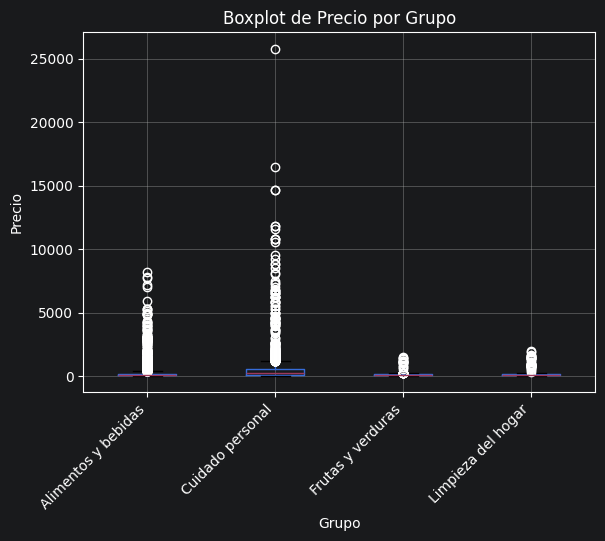

In [888]:
#Para verlo por grupo:

plt.figure(figsize=(10, 5))
df.boxplot(column="Precio", by="Grupo")

plt.title("Boxplot de Precio por Grupo")
plt.suptitle("")
plt.xlabel("Grupo")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

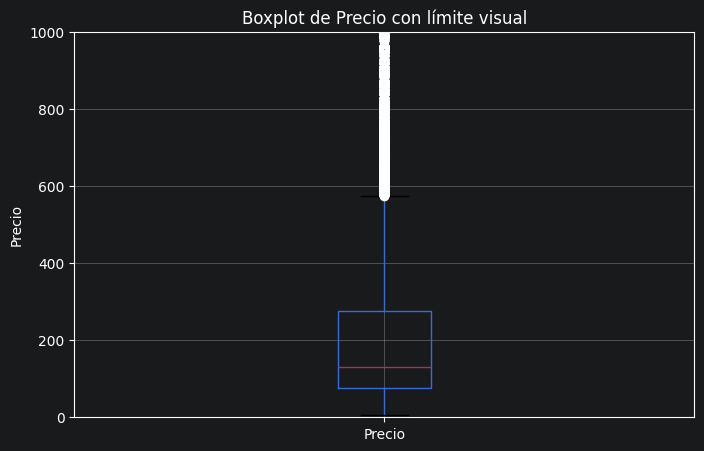

In [889]:
# visualización más clara sin que los extremos aplasten el gráfico:

plt.figure(figsize=(8, 5))
df.boxplot(column="Precio")
plt.ylim(0, 1000)

plt.title("Boxplot de Precio con límite visual")
plt.ylabel("Precio")
plt.show()

In [890]:
# Guardo los outliers por producto para revisarlos si quiero
df_outliers_producto = df[df["Es_outlier_producto"]].copy()

In [891]:
# Elimino los outliers
df = df[~df["Es_outlier_producto"]].reset_index(drop=True)

In [892]:
# Elimino columnas auxiliares
#df = df.drop(columns=["Limite_superior_producto", "Es_outlier_producto"])

In [893]:
df.shape

(24025, 9)

In [894]:
#Verifico eliminados
df_outliers_producto.shape[0]

1144

In [895]:
df

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes
0,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto,80.00,123.75,False,Bajo,4
1,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto Express,99.00,123.75,False,Medio bajo,4
2,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Disco,99.00,123.75,False,Medio bajo,4
3,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Ta - Ta,95.00,123.75,False,Medio bajo,4
4,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Tienda Inglesa,97.00,123.75,False,Medio bajo,4
...,...,...,...,...,...,...,...,...,...
24020,Oct25,Alimentos y bebidas,pescado fresco bifes de merluz - sin marca 1 kg.,Disco,NaN,610.25,False,NaN,10
24021,Nov25,Alimentos y bebidas,"agua mineral sin gas(bidón) salus 6,25lts",Ta - Ta,NaN,154.50,False,NaN,11
24022,Abr25,Cuidado personal,"champú pantene, 400 ml.",El Dorado,NaN,539.95,False,NaN,4
24023,Dic25,Alimentos y bebidas,harina trigo común 0000 primor paquete 1 kg.,Macro,NaN,70.50,False,NaN,12


#### Observaciones y conclusiones

> En este dataset, la variable afectada por outliers es `Precio`, ya que es la única variable numérica relevante.
>
> En una primera revisión general, se observaron precios muy superiores al comportamiento habitual del dataset. Sin embargo, comparar todos los precios entre sí puede ser poco adecuado, porque cada producto tiene un rango de precios propio.
>
> Por ejemplo, un precio alto puede ser normal para productos como protectores solares, pañales, tintas o cremas, pero podría ser atípico para productos más baratos.
>
> Por este motivo, se decidió detectar los outliers de `Precio` comparando cada registro contra los precios de su mismo `Producto`.
>
> Para cada producto se calculó el límite superior utilizando el rango intercuartílico (`IQR`). Luego, se marcaron como outliers aquellos registros cuyo `Precio` superaba el límite superior correspondiente a ese producto.
>
> Finalmente, los registros identificados como outliers por producto fueron separados en `df_outliers_producto` y eliminados del dataframe principal.

#### Análisis de valores faltantes

### Análisis de valores faltantes

Un **valor faltante** (*missing value*) es un dato que no tiene valor asignado en una observación para una variable específica.

Este tipo de valores son comunes y pueden surgir por distintas razones:

- errores en la carga o recolección de datos,
- información no disponible al momento del relevamiento,
- productos sin precio informado,
- supermercados no identificados,
- o datos que no aplican para ciertos registros.

En este dataset, los valores faltantes pueden aparecer en variables como `Grupo`, `Producto`, `Super` y `Precio`. Para tratarlos existen varias estrategias:

- **Eliminarlos**: se eliminan las filas que contienen valores nulos. Es una opción simple, pero puede hacer que se pierda información útil.
- **Imputación numérica**: se utiliza para rellenar valores faltantes en variables numéricas. En este caso, podría aplicarse a `Precio`, reemplazando los nulos por la media, mediana o algún valor calculado por grupo o producto.
- **Imputación categórica**: se utiliza para rellenar valores faltantes en variables categóricas como `Grupo`, `Producto` o `Super`. Una opción habitual es reemplazar los nulos por la moda o por una categoría como `Sin dato`.

En este análisis, antes de decidir si eliminar o imputar, es importante revisar cuántos valores faltantes tiene cada columna y qué impacto tendría eliminarlos.

In [896]:
df.shape[0]

24025

In [897]:
df.isnull().sum()

Periodo                        0
Grupo                        133
Producto                       0
Super                       2444
Precio                       433
Limite_superior_producto       0
Es_outlier_producto            0
Rango_precio_producto        433
Mes                            0
dtype: int64

In [898]:
df.isnull().sum() / df.shape[0]

Periodo                    0.00
Grupo                      0.01
Producto                   0.00
Super                      0.10
Precio                     0.02
Limite_superior_producto   0.00
Es_outlier_producto        0.00
Rango_precio_producto      0.02
Mes                        0.00
dtype: float64

In [899]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Super                      10.17
Rango_precio_producto       1.80
Precio                      1.80
Grupo                       0.55
Periodo                     0.00
Producto                    0.00
Limite_superior_producto    0.00
Es_outlier_producto         0.00
Mes                         0.00
dtype: float64

In [900]:
df[df.isnull().any(axis=1)]

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes
1800,Abr25,NaN,establecimientos relevados,Devoto,23.00,66.00,False,Medio bajo,4
1801,Abr25,NaN,establecimientos relevados,Devoto Express,36.00,66.00,False,Medio alto,4
1802,Abr25,NaN,establecimientos relevados,Disco,29.00,66.00,False,Medio alto,4
1803,Abr25,NaN,establecimientos relevados,El Clon,16.00,66.00,False,Bajo,4
1804,Abr25,NaN,establecimientos relevados,Farmaglobal,10.00,66.00,False,Bajo,4
...,...,...,...,...,...,...,...,...,...
24020,Oct25,Alimentos y bebidas,pescado fresco bifes de merluz - sin marca 1 kg.,Disco,NaN,610.25,False,NaN,10
24021,Nov25,Alimentos y bebidas,"agua mineral sin gas(bidón) salus 6,25lts",Ta - Ta,NaN,154.50,False,NaN,11
24022,Abr25,Cuidado personal,"champú pantene, 400 ml.",El Dorado,NaN,539.95,False,NaN,4
24023,Dic25,Alimentos y bebidas,harina trigo común 0000 primor paquete 1 kg.,Macro,NaN,70.50,False,NaN,12


In [901]:
df.isnull().any(axis=1).sum()

np.int64(2990)

In [902]:
df.columns

Index(['Periodo', 'Grupo', 'Producto', 'Super', 'Precio',
       'Limite_superior_producto', 'Es_outlier_producto',
       'Rango_precio_producto', 'Mes'],
      dtype='str')

In [903]:
# 1. Eliminar filas con valores nulos
df = df.dropna(subset=["Grupo", "Producto", "Super", "Precio"]).reset_index(drop=True)

In [904]:
df[df.isnull().any(axis=1)]

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes


##### Observaciones

> En este dataset se identificaron valores faltantes en variables como `Grupo`, `Producto`, `Super` y `Precio`.
>
> Estos valores faltantes pueden afectar el análisis, especialmente en los cruces por supermercado, producto o grupo, y también en los cálculos estadísticos de `Precio`.
>
> En lugar de imputar estos valores, se decidió eliminar las filas con datos faltantes, ya que el objetivo es trabajar únicamente con registros completos y evitar introducir valores artificiales.

##### Conclusiones

> Se aplicó `dropna()` para eliminar las observaciones incompletas.
>
> Esta decisión permite conservar solo registros con información completa en todas las columnas principales del dataset.
>
> Luego de esta limpieza, los análisis posteriores de precios, productos, grupos, supermercados y períodos se realizan sobre datos completos, reduciendo posibles distorsiones por información faltante.

#### Inferencia de nuevas características


Otro uso típico en esta ingeniería es la de la obtención de nuevas características mediante la "fusión" de dos o más ya existentes. De esta forma podemos simplificar el número de variables y trazar nuevas relaciones con el target.


In [905]:
df["Rango_precio"] = pd.cut(
    df["Precio"],
    bins=[0, 100, 300, 600, df["Precio"].max()],
    labels=["Bajo", "Medio", "Alto", "Muy alto"]
)

In [906]:
df["Rango_precio"].value_counts()

Rango_precio
Bajo        8452
Medio       8217
Alto        2845
Muy alto    1521
Name: count, dtype: int64

#### Observación
>
> En este dataset, la variable `Precio` representa el valor monetario de cada producto relevado. A partir de esta variable se puede crear una nueva característica llamada `Rango_precio`, que permita clasificar los productos en categorías como precio bajo, medio, alto o muy alto.
>
> Esta nueva variable facilita el análisis, ya que permite comparar grupos de productos, supermercados o períodos según rangos de precios, sin depender únicamente del valor exacto del precio.

In [907]:
df["Rango_precio"].value_counts()

Rango_precio
Bajo        8452
Medio       8217
Alto        2845
Muy alto    1521
Name: count, dtype: int64

In [908]:
df["Es_outlier_precio"] = df["Precio"] > df["Limite_superior_producto"]

In [909]:
df["Es_outlier_precio"].value_counts()

Es_outlier_precio
False    21035
Name: count, dtype: int64

#### Observación
>
> Además, dado que la variable `Precio` presenta valores atípicos, se puede crear una nueva característica llamada `Es_outlier_precio`. Esta variable indica si un precio supera el límite superior calculado mediante el rango intercuartílico.
>
> Esto permite conservar la información original, pero identificar fácilmente qué registros tienen precios atípicos para analizarlos por separado.

## Paso 7: Split (dos métodos o enfoques)

[Doc: scikit-learn train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

[Doc: SelectFromModel](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html)
- fit()
- transform()
- get_support()

### Enfoque elegido: Realizar cambios antes de hacer el split de datos

En este enfoque:

- Primero se escala/codifica todo el dataset
- Luego se divide en conjuntos de entrenamiento y prueba.

Ventaja:

Garantiza que los datos de entrenamiento y prueba están procesados de la misma manera, ya que se utilizan los mismos parámetros de escalado y/o sistema de codificación en todo el dataset.

Desventaja:

Introduce información del conjunto de prueba en el conjunto de entrenamiento (porque los parámetros de se calculan usando todo el dataset). Esto puede llevar a una sobreestimación del rendimiento del modelo, ya que el modelo ha "visto" indirectamente la distribución de los datos de test.


## Realizamos el split

In [910]:
df.shape

(21035, 11)

In [911]:
df

,Periodo,Grupo,Producto,Super,Precio,Limite_superior_producto,Es_outlier_producto,Rango_precio_producto,Mes,Rango_precio,Es_outlier_precio
0,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto,80.00,123.75,False,Bajo,4,Bajo,False
1,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto Express,99.00,123.75,False,Medio bajo,4,Bajo,False
2,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Disco,99.00,123.75,False,Medio bajo,4,Bajo,False
3,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Ta - Ta,95.00,123.75,False,Medio bajo,4,Bajo,False
4,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Tienda Inglesa,97.00,123.75,False,Medio bajo,4,Bajo,False
...,...,...,...,...,...,...,...,...,...,...,...
21030,Sep25,Limpieza del hogar,jabón para ropa en barra primor unidad 300 grs.,Farmashop,35.00,59.75,False,Bajo,9,Bajo,False
21031,Sep25,Limpieza del hogar,jabón para ropa en barra primor unidad 300 grs.,Red Expres,39.00,59.75,False,Medio bajo,9,Bajo,False
21032,Sep25,Limpieza del hogar,jabón para ropa en barra primor unidad 300 grs.,Red Market,39.00,59.75,False,Medio bajo,9,Bajo,False
21033,Sep25,Limpieza del hogar,jabón para ropa en barra primor unidad 300 grs.,Ta - Ta,46.00,59.75,False,Alto,9,Bajo,False


In [912]:
# Dropeo columnas de limite de outlier antes de procesar
df = df.drop(columns=["Es_outlier_producto", "Es_outlier_precio", "Limite_superior_producto"], errors="ignore")


In [913]:
df.columns

Index(['Periodo', 'Grupo', 'Producto', 'Super', 'Precio',
       'Rango_precio_producto', 'Mes', 'Rango_precio'],
      dtype='str')

In [914]:
# Crear carpeta si no existe
processed_path = Path('../data/processed')
processed_path.mkdir(parents=True, exist_ok=True)

# Guardar como Excel
df.to_csv(processed_path / "cadenas_unificadas_2025_procesado.csv", index=False)

In [915]:
X = df.drop(columns=["Precio"])
y = df["Precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [916]:
scaler = StandardScaler()

In [917]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

columnas_numericas = X.select_dtypes(include="number").columns
columnas_categoricas = X.select_dtypes(include=["str", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

X_train_preprocesado = preprocessor.fit_transform(X_train)
X_test_preprocesado = preprocessor.transform(X_test)

### Aprendizajes

#### División entre entrenamiento y prueba

Antes de entrenar un modelo, es recomendable dividir los datos en conjuntos de entrenamiento y prueba.

- `X_train`: variables predictoras usadas para entrenar el modelo.
- `X_test`: variables predictoras usadas para evaluar el modelo.
- `y_train`: valores reales usados durante el entrenamiento.
- `y_test`: valores reales usados para evaluar el rendimiento.
- `test_size=0.2`: reserva el 20% de los datos para prueba y utiliza el 80% para entrenamiento.
- `random_state=42`: permite que la división sea reproducible.

#### Escalado y codificación

No todas las columnas se procesan igual:

- Las variables numéricas se pueden escalar con `StandardScaler`.
- Las variables categóricas deben codificarse, por ejemplo con `OneHotEncoder`.
- No se debe aplicar `StandardScaler` directamente sobre columnas de texto como `Periodo`, `Grupo`, `Producto` o `Super`.

#### Evitar data leakage

La forma correcta de transformar los datos es:
```python
fit_transform()  # solo en entrenamiento
transform()      # solo en prueba

## Paso 8: Scaling & Encoding

[Sklearn - documentación de preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html)

El **escalado de valores** (*feature scaling*) es un paso crucial en el preprocesamiento de datos para muchos algoritmos de Machine Learning. Es una técnica que cambia el rango de los valores de los datos para que puedan ser comparables entre sí.

Algunas técnicas son:
- Normalización, que es el proceso de cambiar los valores para que tengan una media de 0 y una desviación estándar de 1.
- Mínimo-Máximo, que transforma los datos para que todos los valores estén entre 0 y 1.

A continuación detallaremos cómo podemos aplicar cada una de ellas, pero recordemos que depende mucho del modelo que vayamos a querer entrenar

#### Normalización

In [918]:
df.select_dtypes(include="number").columns

Index(['Precio', 'Mes'], dtype='str')

In [919]:
from sklearn.preprocessing import StandardScaler

norm_scaler = StandardScaler()

num_variables = ["Precio", "Mes"]

norm_features = norm_scaler.fit_transform(df[num_variables])

df_norm = pd.DataFrame(
    norm_features,
    index=df.index,
    columns=num_variables
)

df_norm.head()

,Precio,Mes
0,-0.58,-0.71
1,-0.49,-0.71
2,-0.49,-0.71
3,-0.51,-0.71
4,-0.50,-0.71


En el paso anterior ya se realizó el preprocesamiento correcto para modelado, utilizando `ColumnTransformer`.
>
> Las variables numéricas se escalaron con `StandardScaler` y las variables categóricas se codificaron con `OneHotEncoder`.
>
> Además, el preprocesamiento se ajustó únicamente sobre `X_train` mediante `fit_transform()` y luego se aplicó sobre `X_test` con `transform()`, evitando data leakage.
>
> Por ese motivo, no es necesario volver a normalizar todo el dataframe completo.

#### Escalado Mínimo-Máximo


In [920]:
from sklearn.preprocessing import MinMaxScaler

num_variables = X_train.select_dtypes(include="number").columns

min_max_scaler = MinMaxScaler()

X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()

X_train_minmax[num_variables] = min_max_scaler.fit_transform(X_train[num_variables])
X_test_minmax[num_variables] = min_max_scaler.transform(X_test[num_variables])

`MinMaxScaler` transforma las variables numéricas para que queden en un rango entre 0 y 1.
>
> A diferencia de `StandardScaler`, que centra los datos usando media y desviación estándar, `MinMaxScaler` conserva la forma de la distribución pero cambia la escala.
>
> Para evitar `data leakage`, el escalador debe ajustarse únicamente con `X_train` y luego aplicarse a `X_test`.

### Encoding - Codificación de variables categóricas


Las variables categóricas, que contienen valores discretos y no numéricos, deben transformarse en una forma que los algoritmos de Machine Learning puedan entender.

Existen varias técnicas de codificación, cada una con sus ventajas y desventajas, dependiendo del tipo de datos y del modelo utilizado.

#### Label Encoding

Asigna un valor entero único a cada categoría.

Adecuado para variables categóricas ordinales donde el orden tiene importancia.

In [921]:
from sklearn.preprocessing import LabelEncoder

# Creo copias de los conjuntos de entrenamiento: X_train | X_test
X_train_cat_le = X_train.copy()
X_test_cat_le = X_test.copy()

#Defino columnas categoricas
columnas_categoricas = ["Periodo", "Grupo", "Producto", "Super"]

#Creo bucle de instancias
for col in columnas_categoricas:
    label_encoder = LabelEncoder()

    label_encoder.fit(X_train[col])

    X_train_cat_le[col + "_le"] = label_encoder.transform(X_train[col])
    X_test_cat_le[col + "_le"] = label_encoder.transform(X_test[col])

X_train_cat_le.head()

,Periodo,Grupo,Producto,Super,Rango_precio_producto,Mes,Rango_precio,Periodo_le,Grupo_le,Producto_le,Super_le
20592,Sep25,Cuidado personal,pasta dental kolynos triple acción unidad 90 grs.,Farmaglobal,Alto,9,Bajo,11,1,311,5
2067,Ago25,Alimentos y bebidas,café envasado (no instantáneo) saint paquete 2...,Red Market,Medio alto,8,Medio,1,0,81,13
15342,May25,Cuidado personal,protector solar spf 60 soundown 120 ml.,Disco,Medio bajo,5,Muy alto,8,1,337,2
13369,Mar25,Cuidado personal,"jabón de tocador ann bow, 140 grs.",Farmashop,Bajo,3,Bajo,7,1,226,6
7884,Feb25,Alimentos y bebidas,manteca conaprole sin sal envase 200 grs.,Devoto,Bajo,2,Bajo,4,0,251,0


#### One-Hot Encoding

Asigna un valor entero único a cada categoría.

Crea una columna binaria (0 o 1) para cada categoría.

Adecuado para variables categóricas nominales donde no hay un orden implícito.

No es conveniente cuando hay muchas categorías.


In [922]:
from sklearn.preprocessing import OneHotEncoder

cat_variables = ["Periodo", "Grupo", "Producto", "Super"]

onehot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

onehot_encoder.fit(X_train[cat_variables])

X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(
    X_train_cat_ohe,
    index=X_train.index,
    columns=onehot_encoder.get_feature_names_out(cat_variables)
)

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(
    X_test_cat_ohe,
    index=X_test.index,
    columns=onehot_encoder.get_feature_names_out(cat_variables)
)

X_train_cat_ohe.head()

,Periodo_Abr25,Periodo_Ago25,Periodo_Dic25,Periodo_Ene25,Periodo_Feb25,Periodo_Jul25,Periodo_Jun25,Periodo_Mar25,Periodo_May25,Periodo_Nov25,Periodo_Oct25,Periodo_Sep25,Grupo_Alimentos y bebidas,Grupo_Cuidado personal,Grupo_Frutas y verduras,Grupo_Limpieza del hogar,Producto_aceite de girasol marca propia envase 900 cc,Producto_aceite de girasol marcas propias envase 900 cc,Producto_aceite de girasol precio líder envase 900 cc,Producto_aceite de girasol río de la plata envase 900 cc,Producto_aceite de girasol tata envase 900 cc,Producto_aceite de girasol tienda inglesa envase 900 cc,Producto_aceite de girasol uruguay envase 900 cc,Producto_aceite de girasol óptimo envase 900 cc,Producto_aceite de maíz delicia envase 900 cc,Producto_aceite de maíz río de la plata envase 900 cc,Producto_aceite de soja condesa envase 900 cc,Producto_aceite de soja río de la plata envase 900 cc,Producto_aceite girasol devoto (envase 900 cc),Producto_aceite girasol optimo (envase 900 cc),Producto_aceite girasol rio de la plata (envase 900 cc),Producto_aceite girasol tata (envase 900 cc),Producto_aceite girasol tienda inglesa (envase 900 cc),Producto_aceite girasol uruguay (envase 900 cc),Producto_aceite maiz delicia (envase 900 cc),Producto_aceite maiz rio de la plata (envase 900 cc),Producto_aceite soja condesa (envase 900 cc),Producto_aceite soja rio de la plata (envase 900 cc),Producto_afeitadora descartable gillette (2 unidades),Producto_afeitadora descartable schick (1 unidad),"Producto_afeitadora gillette mach3 dispenser x2, 2us.","Producto_afeitadora xtreme3 piel delicada x1, 1 unidad",Producto_agua de mesa con gas matutina envase 2 lt.,Producto_agua de mesa con gas nativa envase 2 lt.,"Producto_agua de mesa con gas salus envase 2,25 lt.","Producto_agua de mesa sin gas matutina 2,5 lts","Producto_agua de mesa sin gas salus 2,25 lts","Producto_agua de mesa sin gas vitale 2,5 lts","Producto_agua mineral con gas matutina (envase 2,5 lt.)","Producto_agua mineral con gas nativa (envase 2,5 lt.)","Producto_agua mineral con gas salus (envase 2,25 lt.)","Producto_agua mineral sin gas matutina (envase 2,5lt.)",Producto_agua mineral sin gas nativa (envase 6lt.),"Producto_agua mineral sin gas salus (envase 2,25lt.)","Producto_agua mineral sin gas salus (envase 6,25lt.)","Producto_agua mineral sin gas vitale (envase 2,5lt.)",Producto_agua mineral sin gas(bidón) nativa 6lts,"Producto_agua mineral sin gas(bidón) salus 6,25lts",Producto_aguja con hueso sin marca (1 kg.),Producto_aguja sin hueso sin marca (1 kg.),Producto_aguja vacuna con hueso - sin marca 1 kg.,Producto_aguja vacuna sin hueso - sin marca 1 kg.,Producto_alcohol en gel alcohol en gel bioset (250 ml.),Producto_alcohol en gel bioset 250 ml.,Producto_alcohol rectificado alcohol rectificado drogueria paysandu (250 ml.),Producto_alcohol rectificado droguería paysandú 250 ml.,Producto_algodon algodon zig zag cisne (100 grs.),Producto_algodón zig zag cisne 100 gr.,Producto_arroz blanco aruba tipo patna bolsa 1 kg.,Producto_arroz blanco blue patna bolsa 1 kg.,Producto_arroz blanco green chef bolsa 1 kg.,Producto_arroz blanco pony bolsa 1 kg.,Producto_arroz blanco saman blanco bolsa 1 kg.,Producto_arroz blanco vidarroz bolsa 1 kg.,Producto_arroz calidad alta blue patna (bolsa 1 kg.),Producto_arroz calidad alta green chef (bolsa 1 kg.),Producto_arroz calidad alta saman blanco (bolsa 1 kg.),Producto_arroz calidad media aruba (bolsa 1 kg.),Producto_arroz calidad media pony (bolsa 1 kg.),Producto_arroz calidad media vidarroz (bolsa 1 kg.),Producto_arvejas en conserva cololo (lata 380 grs.),Producto_arvejas en conserva cololó lata 380 grs.,Producto_arvejas en conserva nidemar (lata 300 grs.),Producto_arvejas en conserva nidemar lata 300 grs.,Producto_azucar blanca azucarlito (paquete 1 kg.),Producto_azucar blanca bella union (paquete 1 kg.),Producto_azúcar blanco azucarlito paquete 1 kg.,Producto_azúcar blanco bella unión paquete 1 kg.,Producto_banana brasil sin marca (1 kg.),"Producto_banana brasil, 1 kg

#### Ordinal Encoding

Similar a Label Encoding, pero permite especificar el orden de las categorías.

Adecuado para variables categóricas ordinales.

In [923]:
df_example = df[["Rango_precio_producto"]].copy()

df_example.head(15)

,Rango_precio_producto
0,Bajo
1,Medio bajo
2,Medio bajo
3,Medio bajo
4,Medio bajo
5,Medio bajo
6,Medio alto
7,Medio bajo
8,Medio bajo
9,Alto


In [924]:
mapa_rango_precio = {
    "Bajo": 1,
    "Medio bajo": 2,
    "Medio alto": 3,
    "Alto": 4
}

df["Rango_precio_producto_ordinal"] = df["Rango_precio_producto"].map(mapa_rango_precio)

In [925]:
df_example

,Rango_precio_producto
0,Bajo
1,Medio bajo
2,Medio bajo
3,Medio bajo
4,Medio bajo
...,...
21030,Bajo
21031,Medio bajo
21032,Medio bajo
21033,Alto


In [926]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(
    categories=[["Bajo", "Medio bajo", "Medio alto", "Alto"]]
)

df["Rango_precio_producto_ordinal"] = ordinal_encoder.fit_transform(
    df[["Rango_precio_producto"]]
)

df[["Rango_precio_producto", "Rango_precio_producto_ordinal"]].head(15)

,Rango_precio_producto,Rango_precio_producto_ordinal
0,Bajo,0.00
1,Medio bajo,1.00
2,Medio bajo,1.00
3,Medio bajo,1.00
4,Medio bajo,1.00
5,Medio bajo,1.00
6,Medio alto,2.00
7,Medio bajo,1.00
8,Medio bajo,1.00
9,Alto,3.00


In [927]:
# Para que comience en 1
df["Rango_precio_producto_ordinal"] = df["Rango_precio_producto_ordinal"] + 1

In [928]:
df[["Rango_precio_producto", "Rango_precio_producto_ordinal"]].head(20)

,Rango_precio_producto,Rango_precio_producto_ordinal
0,Bajo,1.00
1,Medio bajo,2.00
2,Medio bajo,2.00
3,Medio bajo,2.00
4,Medio bajo,2.00
5,Medio bajo,2.00
6,Medio alto,3.00
7,Medio bajo,2.00
8,Medio bajo,2.00
9,Alto,4.00


### Guardando los scalers & encoders


In [929]:
# Guardamos utilizando Pickle (que nos permite guardar objetos de Python)
import pickle
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)

with open("../models/precios_2025_procesado.pkl", "wb") as file:
    pickle.dump(preprocessor, file)

## Paso 9: Selección de características


La **selección de características** (*feature selection*) es un proceso que implica seleccionar las características (variables) más relevantes de nuestro conjunto de datos para usarlas en la construcción de un modelo de Machine Learning, desechando el resto.

Existen varias razones para incluirlo en nuestro análisis exploratorio:

1. Simplificar el modelo para que sea más fácil de entender e interpretar.
2. Reducir el tiempo de entrenamiento del modelo.
3. Evitar el sobre-ajuste al reducir la dimensionalidad del modelo y minimizar el ruido y las correlaciones innecesarias.
4. Mejorar el rendimiento del modelo al eliminar las características irrelevantes.

Además, existen diversas técnicas para la selección de características. Muchas de ellas se basan a su vez en modelos supervisados entrenados o de clustering y tienes más información.

La librería `sklearn` contiene gran parte de las mejores alternativas para llevarla a cabo. Una de las herramientas que más se utilizan para realizar procesos de selección de características rápidos y con buenos resultados es `SelectKBest`. Esta función selecciona las `k` mejores características de nuestro conjunto de datos basándose en una función de un test estadístico. Este test estadístico normalmente es un ANOVA o un Chi-Cuadrado:

In [930]:
from sklearn.feature_selection import SelectKBest, f_regression

selection_model = SelectKBest(score_func=f_regression, k=5)

selection_model.fit(X_train_preprocesado, y_train)

X_train_sel = selection_model.transform(X_train_preprocesado)
X_test_sel = selection_model.transform(X_test_preprocesado)

In [931]:
feature_names = preprocessor.get_feature_names_out()

variables_seleccionadas = feature_names[selection_model.get_support()]

variables_seleccionadas

array(['cat__Grupo_Cuidado personal',
       'cat__Producto_pañales babysec premium extra extra grande, 48 us.',
       'cat__Rango_precio_Alto', 'cat__Rango_precio_Bajo',
       'cat__Rango_precio_Muy alto'], dtype=object)

In [932]:
X_train_sel = pd.DataFrame(
    X_train_sel.toarray(),
    columns=variables_seleccionadas,
    index=X_train.index
)

X_test_sel = pd.DataFrame(
    X_test_sel.toarray(),
    columns=variables_seleccionadas,
    index=X_test.index
)

X_train_sel.head()

,cat__Grupo_Cuidado personal,"cat__Producto_pañales babysec premium extra extra grande, 48 us.",cat__Rango_precio_Alto,cat__Rango_precio_Bajo,cat__Rango_precio_Muy alto
20592,1.00,0.00,0.00,1.00,0.00
2067,0.00,0.00,0.00,0.00,0.00
15342,1.00,0.00,0.00,0.00,1.00
13369,1.00,0.00,0.00,1.00,0.00
7884,0.00,0.00,0.00,1.00,0.00


La selección de características, al igual que el entrenamiento del modelo en general, debe realizarse solo sobre el conjunto de entrenamiento y no sobre la totalidad del dataset.

Si se realizara sobre todos los datos, se podría introducir un sesgo conocido como **contaminación de datos** (*data leakage*). Esto ocurre cuando información del conjunto de prueba se utiliza indirectamente para tomar decisiones durante el entrenamiento, lo que puede llevar a una estimación demasiado optimista del rendimiento del modelo.

Por eso, la mejor práctica es dividir primero los datos en conjuntos de entrenamiento y prueba. Luego, la selección de características se ajusta únicamente con los datos de entrenamiento y se aplica posteriormente tanto al conjunto de entrenamiento como al conjunto de prueba.

En este caso, como la variable objetivo es `Precio`, se utiliza una selección de características orientada a regresión (`f_regression`) en lugar de Chi cuadrado. Las características seleccionadas se obtienen a partir del conjunto de entrenamiento ya preprocesado, utilizando las variables generadas por el `ColumnTransformer`.

In [933]:
variables_seleccionadas

array(['cat__Grupo_Cuidado personal',
       'cat__Producto_pañales babysec premium extra extra grande, 48 us.',
       'cat__Rango_precio_Alto', 'cat__Rango_precio_Bajo',
       'cat__Rango_precio_Muy alto'], dtype=object)

Las características seleccionadas por el modelo fueron:

In [934]:
variables_seleccionadas

array(['cat__Grupo_Cuidado personal',
       'cat__Producto_pañales babysec premium extra extra grande, 48 us.',
       'cat__Rango_precio_Alto', 'cat__Rango_precio_Bajo',
       'cat__Rango_precio_Muy alto'], dtype=object)